# Proyecto 2 Bioseñales 

**Estudiantes:**

Luisa María Hernández Quintero 

Karen Agudelo Toro 

# Marco teorico 

**El algoritmo de Patrones Espaciales Comunes (CSP):** es una técnica de filtrado espacial supervisada que está diseñada específicamente para problemas de clasificación binaria o multiclase en señales de EEG. A diferencia de los filtros temporales o espectrales (como Fourier o Welch) que observan cuándo y en qué frecuencia oscila la señal, CSP observa dónde ocurren los cambios de energía en la corteza cerebral [1].

Matemáticamente, el objetivo de CSP es transformar la matriz de datos original de los canales de EEG mediante una matriz de proyección lineal $W$. El criterio de optimización del algoritmo consiste en encontrar direcciones espaciales (filtros) que maximicen la varianza ( en este caso la potencia) de la señal filtrada para una condición clínica o tarea motora, mientras minimizan simultáneamente la varianza para la otra condición [1].

El índice CSP es considerado uno de los descriptores más dicientes y eficientes en Interfaces Cerebro-Computador (BCI) dado que:

* El cráneo y las capas meníngeas actúan como conductores que dispersan los potenciales eléctricos. Esto causa que el canal Cz capte actividad de C3 o C4, difuminando los patrones. CSP resuelve esto combinando los canales ponderadamente para aislar matemáticamente la fuente exacta de la corteza sensoriomotora.

* Los fenómenos de Desincronización Relacionada con Eventos (ERD) provocan pequeñas caídas de amplitud en el hemisferio opuesto. CSP amplifica  este contraste. Mientras que en una gráfica de potencia normal la diferencia entre imaginación izquierda y derecha puede ser de apenas fracciones diminutas de voltios, después de aplicar CSP la separación entre clases se vuelve evidente.

* Permite comprimir información de múltiples electrodos en solo un par de componentes espaciales virtuales, reteniendo únicamente la información geométrica útil para la predicción y descartando el ruido muscular o ambiental de fondo.

Dado que la señal de EEG se encuentra previamente filtrada por software en una banda de frecuencias de interés (como el ritmo Mu o Beta), la varianza de la señal en el tiempo equivale directamente a la potencia o amplitud de dicha banda. El índice numérico que se extrae para entregarle al clasificador es el logaritmo de la varianza de estas señales ya proyectadas y limpias.

En este proyecto, el CSP opera sobre el Bloque 1 de datos (b1_ei y b1_ed), el cual conserva un mapa extendido de 7 canales del área motora (['C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6']). El algoritmo requiere obligatoriamente una estructura binaria etiquetada (Izquierda frente a Derecha) para entrenar sus matrices de covarianza. El proceso se ejecuta de forma independiente para  ['mu'] y para  ['beta']. Las señales de los 7 canales físicos se proyectan en componentes virtuales, se calcula su varianza logarítmica por cada época de 2 segundos y estos índices limpios se usan para alimentar clasificadores.


**Coherencia Espectral de Magnitud Cuadrada (MSC)**
La Coherencia Espectral es una métrica estadística utilizada para cuantificar el grado de sincronización lineal o acoplamiento funcional entre dos señales en el dominio de la frecuencia. A diferencia de la Potencia Espectral (PSD), que evalúa la actividad de un solo electrodo de forma aislada, la coherencia examina la interacción y la conectividad de la red cerebral [2]. Matemáticamente, la coherencia de magnitud cuadrada $C_{xy}(f)$ entre dos canales $x(t)$ y $y(t)$ a una frecuencia dada $f$ se define mediante la ecuación: 

$$C_{xy}(f) = \frac{|P_{xy}(f)|^2}{P_{xx}(f)P_{yy}(f)}$$

Donde $P_{xy}$ representa la densidad espectral cruzada entre ambas señales, mientras que $P_{xx}(f)$ y $P_{yy}(f)$ son las densidades espectrales de potencia de cada canal por separado [2]. El resultado de esta ecuación es un índice adimensional acotado estrictamente entre 0 y 1, donde 0 indica una independencia matemática absoluta entre los electrodos y 1 representa una sincronización perfecta de fase y amplitud.

Este índice es fundamental para un sistema BCI porque la imaginación motora no solo altera la energía local de un electrodo, sino que reorganiza las autopistas de comunicación interhemisférica. Durante el reposo, las áreas motoras izquierda y derecha suelen mantener una alta coherencia de fondo. Cuando el sujeto imagina un movimiento unilateral, la red se desincroniza de forma asimétrica, provocando una caída drástica de la coherencia entre el hemisferio que ejecuta la orden y el resto de la corteza, lo que proporciona un patrón altamente diciente para la clasificación.

La coherencia se calcula sobre el Bloque 0 (b0_er, b0_ei, b0_ed), el cual contiene los datos en crudo (filtrados de 0.5 a 45 Hz) de los tres canales principales: C3, Cz y C4. Al ser una medida que puede evaluarse por condición independiente, se calcula la coherencia para cada época en tres pares de canales lógicos: C3-C4 (interhemisférica), C3-Cz (izq-centro) y C4-Cz(der-centro). La función devuelve una curva de coherencia sobre el espectro, y de forma idéntica a la PSD, se extrae el promedio del rango de 8-13 Hz para el índice en Mu, y de 13-30 Hz para el índice en Beta.



**Entropía de Permutación (PE)**
La Entropía de Permutación es una medida de codificación temporal no lineal diseñada para cuantificar el grado de desorden, complejidad o regularidad dinámica de una serie de tiempo. Fue introducida por Bandt y Pompe y destaca por su capacidad de analizar sistemas biológicos complejos y caóticos como el cerebro, siendo sumamente robusta ante el ruido de fondo [3]. El algoritmo opera convirtiendo la señal continua de EEG en una secuencia de patrones u ordenamientos ordinales (motivos espaciales) basados en la comparación de amplitudes de puntos de tiempo vecinos, definidos por un orden de incrustación $m$ y un retraso temporal $\tau$. Tras mapear la frecuencia de aparición de cada posible combinación u ordenamiento de ondas, se calcula la entropía de Shannon sobre dicha distribución de probabilidad [3]. Una señal perfectamente predecible, repetitiva o periódica generará una entropía cercana a 0. Una señal caótica, desordenada y con alta variabilidad generará una entropía cercana a 1


En el procesamiento de EEG, la entropía es un índice sumamente diciente para detectar los cambios sutiles del estado mental. Cuando el sujeto se encuentra en reposo, las neuronas de la corteza motora disparan de forma sincronizada, produciendo un ritmo rítmico, suave y predecible (baja entropía). Al iniciar la imaginación motora, las poblaciones neuronales se desincronizan (ERD) para procesar la información, volviendo la señal del EEG extremadamente compleja, impredecible y desordenada, lo que se traduce en un incremento medible en el valor de la entropía.

La entropía requiere evaluar canales de forma individual y sobre ondas de tiempo específicas de un ritmo. Para ello, se utiliza el Bloque 2 (b2_er, b2_ei, b2_ed), el cual entrega las épocas segmentadas por condición, reducidas a los canales C3, Cz, C4 y filtradas previamente en el tiempo por software. Para cada época de 2 segundos, se extrae el arreglo numérico del canal y se calcula secuencialmente el índice de entropía tanto para la señal sintonizada en Mu () como para la señal en Beta (), generando variables estables y limpias en el dominio del tiempo para entrenar los clasificadores. 


# Programación 

In [1]:
import mne
import matplotlib.pyplot as plt
import numpy as np
from tabulate import tabulate
import pandas as pd
import os
import mne
import os
import glob
import numpy as np
import pandas as pd
from tabulate import tabulate
from mne.decoding import CSP
from scipy.signal import coherence
from antropy import perm_entropy


## Punto 1: Función de procesamiento de señales y de índices  

### Función de procesamiento de señal 

In [2]:
#Definicion de funciones necesarias para el procesamiento
def procesar_archivo_unificada(ruta):
    #Extraccion del sujeto y run 
    nombre = os.path.basename(ruta)
    partes = nombre.split('_')
    
    # Extraccion del sujeto
    sujeto = partes[0]
    #Extraccion del run
    run_con_extension = partes[2].split('-')[1]
    run = run_con_extension.split('.')[0]
    
    # Carga del EEG con MNE
    raw = mne.io.read_raw_eeglab(ruta, preload=True, verbose=False)
    
    # Se aplica el filtro Notch a 60Hz y el pasa-banda genérico de 0.5 a 45 Hz
    raw.notch_filter(60, verbose=False)
    raw.filter(0.5, 45, verbose=False)
    
    # Extraccion de eventos 
    events, event_id = mne.events_from_annotations(raw, verbose=False)
    #Mapeo de eventos
    eventos_dict = {
        'reposo':    event_id.get('TASK1T0') or event_id.get('TASK2T0'),
        'izquierda': event_id.get('TASK1T1') or event_id.get('TASK2T1'),
        'derecha':   event_id.get('TASK1T2') or event_id.get('TASK2T2')
    }
    
    # Se limpian los eventos inexistentes
    eventos_dict = {k: v for k, v in eventos_dict.items() if v is not None}
    
    if not eventos_dict:
        print(f"Advertencia: No se encontraron eventos esperados en {nombre}")
        return None, None, None, None, None, None, None, None, None, sujeto + '_' + run, run

    # Se define la lista de canales garantizados en la corteza motora para el CSP
    canales_motores_csp = ['C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6']
    
    #ventanas temporales
    tmin, tmax = 0.0, 2.0
    
  
    # GENERACIÓN DEL BLOQUE 0: Para PSD y Coherencia Espectral
  
    raw_bloque0 = raw.copy().pick(['C3', 'Cz', 'C4'])
    epocas_b0 = mne.Epochs(raw_bloque0, events, event_id=eventos_dict, tmin=tmin, tmax=tmax, baseline=None, preload=True, verbose=False)
    
    #separacion por condicion
    b0_er = epocas_b0['reposo'] if 'reposo' in epocas_b0.event_id else None
    b0_ei = epocas_b0['izquierda'] if 'izquierda' in epocas_b0.event_id else None
    b0_ed = epocas_b0['derecha'] if 'derecha' in epocas_b0.event_id else None
    
   
    # GENERACIÓN DEL BLOQUE 1: Para Patrones Espaciales Comunes (CSP)
    raw_bloque1 = raw.copy().pick(canales_motores_csp)
    epocas_b1 = mne.Epochs(raw_bloque1, events, event_id=eventos_dict, tmin=tmin, tmax=tmax, baseline=None, preload=True, verbose=False)
    
    ep_rep_csp = epocas_b1['reposo'] if 'reposo' in epocas_b1.event_id else None
    ep_izq_csp = epocas_b1['izquierda'] if 'izquierda' in epocas_b1.event_id else None
    ep_der_csp = epocas_b1['derecha'] if 'derecha' in epocas_b1.event_id else None
    
    #filtrado especifico para bandas mu y beta
    b1_er = {'mu': ep_rep_csp.copy().filter(8.0, 13.0, verbose=False), 'beta': ep_rep_csp.copy().filter(13.0, 30.0, verbose=False)} if ep_rep_csp is not None else None
    b1_ei = {'mu': ep_izq_csp.copy().filter(8.0, 13.0, verbose=False), 'beta': ep_izq_csp.copy().filter(13.0, 30.0, verbose=False)} if ep_izq_csp is not None else None
    b1_ed = {'mu': ep_der_csp.copy().filter(8.0, 13.0, verbose=False), 'beta': ep_der_csp.copy().filter(13.0, 30.0, verbose=False)} if ep_der_csp is not None else None
    
   
    # GENERACIÓN DEL BLOQUE 2: Para Entropía de Permutación
    b2_er = {'mu': b0_er.copy().filter(8.0, 13.0, verbose=False), 'beta': b0_er.copy().filter(13.0, 30.0, verbose=False)} if b0_er is not None else None
    b2_ei = {'mu': b0_ei.copy().filter(8.0, 13.0, verbose=False), 'beta': b0_ei.copy().filter(13.0, 30.0, verbose=False)} if b0_ei is not None else None
    b2_ed = {'mu': b0_ed.copy().filter(8.0, 13.0, verbose=False), 'beta': b0_ed.copy().filter(13.0, 30.0, verbose=False)} if b0_ed is not None else None
    
    return (b0_er, b0_ei, b0_ed, b1_er, b1_ei, b1_ed, b2_er, b2_ei, b2_ed, sujeto, run)

In [3]:
# 1. Ejecutar la función para extraer todo
b0_er, b0_ei, b0_ed, b1_er, b1_ei, b1_ed, b2_er, b2_ei, b2_ed, s, r = procesar_archivo_unificada('sub-001_task-motion_run-4_eeg.set')

# 2. Visualizacion de resultados
print(f"SUJETO: {s} | RUN: {r}\n")

print("--- BLOQUE 0: Para Potencia (PSD) y Coherencia ---")
print(f"Reposo (3 canales: C3, Cz, C4)    : {b0_er}")
print(f"Izquierda (3 canales: C3, Cz, C4) : {b0_ei}")
print(f"Derecha (3 canales: C3, Cz, C4)   : {b0_ed}\n")

print("--- BLOQUE 1: Para CSP (7 canales para geometría) ---")
print(f"Izquierda en Ritmo Mu (8-13 Hz)   : {b1_ei['mu'] if b1_ei else None}")
print(f"Izquierda en Ritmo Beta (13-30 Hz): {b1_ei['beta'] if b1_ei else None}")
print(f"Derecha en Ritmo Mu (8-13 Hz)     : {b1_ed['mu'] if b1_ed else None}")
print(f"Derecha en Ritmo Beta (13-30 Hz)  : {b1_ed['beta'] if b1_ed else None}\n")

print("--- BLOQUE 2: Para Entropía (3 canales filtrados) ---")
print(f"Reposo en Ritmo Mu (8-13 Hz)      : {b2_er['mu'] if b2_er else None}")
print(f"Izquierda en Ritmo Beta (13-30 Hz): {b2_ei['beta'] if b2_ei else None}")
print(f"Derecha en Ritmo Beta (13-30 Hz)  : {b2_ed['beta'] if b2_ed else None}")

SUJETO: sub-001 | RUN: 4

--- BLOQUE 0: Para Potencia (PSD) y Coherencia ---
Reposo (3 canales: C3, Cz, C4)    : <Epochs | 15 events (all good), 0 – 2 s (baseline off), ~145 KiB, data loaded,
 'reposo': 15>
Izquierda (3 canales: C3, Cz, C4) : <Epochs | 8 events (all good), 0 – 2 s (baseline off), ~92 KiB, data loaded,
 'izquierda': 8>
Derecha (3 canales: C3, Cz, C4)   : <Epochs | 7 events (all good), 0 – 2 s (baseline off), ~85 KiB, data loaded,
 'derecha': 7>

--- BLOQUE 1: Para CSP (7 canales para geometría) ---
Izquierda en Ritmo Mu (8-13 Hz)   : <Epochs | 8 events (all good), 0 – 2 s (baseline off), ~175 KiB, data loaded,
 'izquierda': 8>
Izquierda en Ritmo Beta (13-30 Hz): <Epochs | 8 events (all good), 0 – 2 s (baseline off), ~175 KiB, data loaded,
 'izquierda': 8>
Derecha en Ritmo Mu (8-13 Hz)     : <Epochs | 7 events (all good), 0 – 2 s (baseline off), ~158 KiB, data loaded,
 'derecha': 7>
Derecha en Ritmo Beta (13-30 Hz)  : <Epochs | 7 events (all good), 0 – 2 s (baseline off)

### Función de cálculo de PSD 

In [4]:
def calcular_psd_epochs(epocas):
    """
    Calcula la Densidad Espectral de Potencia (PSD) usando el método de Welch
    para las épocas de los canales seleccionados (C3, Cz, C4).
    """
    # Verificación de seguridad por si el archivo fue descartado previamente
    if epocas is None:
        return None, None
    
    #calculo de PSD con el metodo de WELCH    
    psds_obj = epocas.compute_psd(
        method='welch',
        fmin=0.5,       # Alineado con el filtro pasa-altas  para derivadas lentas y artefactos DC
        fmax=45.0,      # Alineado con el filtro pasa-bajas, evita frecuencias musculares altas y ruido
        n_fft=256,      #numero de puntos para la FFT
        n_overlap=128,  #numero de puntos de solapamiento
        verbose=False
    )
    
    # Extraemos los datos (epochs, canales, frecuencias) y el vector de frecuencias
    return psds_obj.get_data(), psds_obj.freqs


def potencia_banda(psds, freqs, fmin, fmax):
    """
    Calcula la potencia promedio en un rango de frecuencias específico (fmin a fmax)
    para cada época y cada canal.
    """
    if psds is None or freqs is None:
        return None

    idx = (freqs >= fmin) & (freqs <= fmax)
    
    # psds tiene la forma: (n_epocas, n_canales, n_frecuencias)
    # Calculamos el promedio en el eje 2 (frecuencias)
    potencia = np.mean(psds[:, :, idx], axis=2)
    
    # Retorna una matriz de forma (n_epocas, n_canales) -> (Épocas, 3 canales)
    return potencia

### Función de cálculo de MSC

In [5]:
def calcular_msc_epochs(epocas, fs=160):
    """
    Calcula la coherencia espectral por época
    entre pares de canales.
    
    Retorna:
    coherencias -> diccionario con matrices
    freqs -> vector de frecuencias
    """
    
    if epocas is None:
        return None, None
    
    datos = epocas.get_data() #obtenemos: n_epocas, n_canales, n_muestras
    
    pares = {
        'C3_C4': (0, 2),
        'C3_Cz': (0, 1),
        'C4_Cz': (2, 1)
    }
    
    resultados = {}
    
    for nombre_par, (ch1, ch2) in pares.items():
        
        coherencias_par = []
        
        for epoch in datos:
            
            señal1 = epoch[ch1]
            señal2 = epoch[ch2]
            
            freqs, coh = coherence(
                señal1,
                señal2,
                fs=fs,
                nperseg=128
            )
            
            coherencias_par.append(coh)
        
        resultados[nombre_par] = np.array(coherencias_par)
    
    return resultados, freqs

#Extraer coherencia por banda
def coherencia_banda(coherencias, freqs, fmin, fmax):
    """
    Calcula la coherencia promedio
    en una banda de frecuencia.
    """
    
    idx = (freqs >= fmin) & (freqs <= fmax)
    
    resultados = {}
    
    for par, valores in coherencias.items():
        
        resultados[par] = np.mean(
            valores[:, idx],
            axis=1
        )
    
    return resultados
#Cada vector contiene una coherencia promedio por epoca



### Función de cálculo de entropia 

In [6]:
#Funcion entropia
def calcular_entropia_epochs(epocas, orden=3, delay=1):
    """
    Calcula entropía de permutación
    por época y por canal.
    """
    
    if epocas is None:
        return None
    
    datos = epocas.get_data()
    
    resultados = []
    
    for epoch in datos:
        
        entropias_canales = []
        
        for canal in epoch:
            
            pe = perm_entropy(
                canal,
                order=orden,
                delay=delay,
                normalize=True
            )
            
            entropias_canales.append(pe)
        
        resultados.append(entropias_canales)
    
    return np.array(resultados)
#retorna una matriz: (n_epocas, n_canales) con la entropía de cada canal por época



### Construcción de data frame principal 

In [7]:
#Se hace una función aparte para el dataframe de PSD porque PSD necesita 2 niveles, primero se obtiene toda la curva espectral y de alli, se selccionan bandas, etc.
def construir_dataframe_psd(ep_reposo, ep_izq, ep_der, sujeto, run):

    filas = []

    tareas_mapeo = {
        'reposo': (ep_reposo, 0),
        'izquierda': (ep_izq, 1),
        'derecha': (ep_der, 2)
    }

    for nombre_tarea, (objeto_epocas, codigo_tarea) in tareas_mapeo.items():

        if objeto_epocas is None:
            continue

        psds, freqs = calcular_psd_epochs(objeto_epocas)

        potencia_mu = potencia_banda(psds, freqs, 8, 13)
        potencia_beta = potencia_banda(psds, freqs, 13, 30)

        n_epocas = potencia_mu.shape[0]

        for i in range(n_epocas):

            fila = {
                'Sujeto': sujeto,
                'run': run,
                'tarea': codigo_tarea,
                'epoch_id': i,

                'PSD_mu_C3': potencia_mu[i, 0],
                'PSD_mu_Cz': potencia_mu[i, 1],
                'PSD_mu_C4': potencia_mu[i, 2],

                'PSD_beta_C3': potencia_beta[i, 0],
                'PSD_beta_Cz': potencia_beta[i, 1],
                'PSD_beta_C4': potencia_beta[i, 2]
            }

            filas.append(fila)

    return pd.DataFrame(filas)

### Extracción para incluir en data frame índices consultados 

#### Extracción de datos de CSP

In [8]:

def extraer_features_csp(b1_er, b1_ei, b1_ed, sujeto, run, ritmo='mu'):
    """
    Extrae características CSP entrenando con Izquierda y Derecha,
    y proyecta también el Reposo (Tarea 0). Construye un DataFrame unificado.
    """

    if b1_er is None or b1_ei is None or b1_ed is None:
        print(f"Faltan épocas para CSP en {sujeto} run {run}.")
        return None, None

    # 1. EXTRACCIÓN DE SEÑALES EN EL TIEMPO
    X_rep = b1_er[ritmo].get_data()  # Datos Reposo
    X_izq = b1_ei[ritmo].get_data()  # Datos Izquierda
    X_der = b1_ed[ritmo].get_data()  # Datos Derecha

    # Etiquetas numéricas para las tareas activas
    y_izq = np.ones(X_izq.shape[0]) * 1
    y_der = np.ones(X_der.shape[0]) * 2

    # 2. CONCATENACIÓN ESTRICTA PARA ENTRENAMIENTO (Solo clases activas)
    X_tren = np.concatenate((X_izq, X_der), axis=0)
    y_tren = np.concatenate((y_izq, y_der), axis=0)

    # 3. CONFIGURACIÓN DEL MODELO CSP
    csp_modelo = CSP(
        n_components=4,
        reg=None,
        log=True,
        transform_into='average_power'
    )

    # El modelo se entrena y se aplica a los datos de movimiento
    features_movimiento = csp_modelo.fit_transform(X_tren, y_tren)
    
    # 4. EL TRUCO DE INGENIERÍA: Proyectar el reposo usando el filtro entrenado
    # Aplicamos las mismas ecuaciones espaciales al bloque de calma cerebral
    features_reposo = csp_modelo.transform(X_rep)

    # 5. CONSTRUCCIÓN DE LAS COLUMNAS DE CARACTERÍSTICAS
    columnas = [
        f'CSP_{ritmo}_comp1',
        f'CSP_{ritmo}_comp2',
        f'CSP_{ritmo}_comp3',
        f'CSP_{ritmo}_comp4'
    ]

    # Unimos los renglones matemáticos de las 3 tareas en una sola matriz gigante
    features_total = np.concatenate((features_reposo, features_movimiento), axis=0)
    df_csp = pd.DataFrame(features_total, columns=columnas)

    # 6. ASIGNACIÓN ORDENADA DE VARIABLES DE CONTROL
    # Generamos el vector de etiquetas final respetando el nuevo orden exacto
    y_total = np.concatenate((
        np.zeros(X_rep.shape[0]),  # Tarea 0 (Reposo)
        y_izq,                     # Tarea 1 (Izquierda)
        y_der                      # Tarea 2 (Derecha)
    ), axis=0)
    
    df_csp['tarea'] = y_total.astype(int)
    df_csp['Sujeto'] = sujeto
    df_csp['run'] = run

    # Separación y conteo de ID de épocas por cada clase independiente
    n_rep = X_rep.shape[0]
    n_izq = X_izq.shape[0]
    n_der = X_der.shape[0]

    epoch_rep = list(range(n_rep))
    epoch_izq = list(range(n_izq))
    epoch_der = list(range(n_der))

    df_csp['epoch_id'] = epoch_rep + epoch_izq + epoch_der

    # Reordenamiento estético de las columnas para el dataset maestro
    columnas_finales = [
        'Sujeto',
        'run',
        'tarea',
        'epoch_id'
    ] + columnas

    df_csp = df_csp[columnas_finales]

    return df_csp, csp_modelo

comp1 (El especialista en la Izquierda): Es un filtro diseñado para amplificar al máximo la señal cuando imaginas mover la mano izquierda y apagarla por completo cuando imaginas la derecha. 

comp2 (El asistente de la Izquierda): Hace un trabajo similar al primero, pero captura detalles secundarios o sutiles del hemisferio derecho del cerebro que ayudan a confirmar la tarea.

comp3 (El asistente de la Derecha): Es el gemelo del componente 2, pero empieza a buscar patrones que favorecen la detección de la mano derecha.

comp4 (El especialista en la Derecha): Es el filtro diseñado para hacer lo contrario al primero: amplifica la señal al máximo cuando imaginas mover la mano derecha y la destruye por completo si piensas en la izquierda.

#### Extracción de datos de MSC

In [9]:
def extraer_features_msc(b0_er, b0_ei, b0_ed, sujeto, run, ritmo='mu'):
    """
    Extrae características de coherencia espectral (MSC) para 
    Reposo (0), Izquierda (1) y Derecha (2) en un DataFrame unificado.
    """
    if b0_er is None or b0_ei is None or b0_ed is None:
        print(f"Faltan épocas para calcular coherencia en {sujeto} run {run}.")
        return None
    
    # Calcular coherencias usando tus funciones matemáticas originales
    coh_r, freqs = calcular_msc_epochs(b0_er)
    coh_i, _     = calcular_msc_epochs(b0_ei)
    coh_d, _     = calcular_msc_epochs(b0_ed)
    
    fmin, fmax = (8, 13) if ritmo == 'mu' else (13, 30)
    
    # Filtrar por la banda elegida
    coh_b_rep = coherencia_banda(coh_r, freqs, fmin, fmax)
    coh_b_izq = coherencia_banda(coh_i, freqs, fmin, fmax)
    coh_b_der = coherencia_banda(coh_d, freqs, fmin, fmax)
    
    filas = []
    
    # --- TAREA 0: REPOSO ---
    for i in range(len(coh_b_rep['C3_C4'])):
        filas.append({
            'Sujeto': sujeto, 'run': run, 'tarea': 0, 'epoch_id': i,
            f'MSC_{ritmo}_C3_C4': coh_b_rep['C3_C4'][i],
            f'MSC_{ritmo}_C3_Cz': coh_b_rep['C3_Cz'][i],
            f'MSC_{ritmo}_C4_Cz': coh_b_rep['C4_Cz'][i]
        })
        
    # --- TAREA 1: MANO IZQUIERDA ---
    for i in range(len(coh_b_izq['C3_C4'])):
        filas.append({
            'Sujeto': sujeto, 'run': run, 'tarea': 1, 'epoch_id': i,
            f'MSC_{ritmo}_C3_C4': coh_b_izq['C3_C4'][i],
            f'MSC_{ritmo}_C3_Cz': coh_b_izq['C3_Cz'][i],
            f'MSC_{ritmo}_C4_Cz': coh_b_izq['C4_Cz'][i]
        })
    
    # --- TAREA 2: MANO DERECHA ---
    for i in range(len(coh_b_der['C3_C4'])):
        filas.append({
            'Sujeto': sujeto, 'run': run, 'tarea': 2, 'epoch_id': i,
            f'MSC_{ritmo}_C3_C4': coh_b_der['C3_C4'][i],
            f'MSC_{ritmo}_C3_Cz': coh_b_der['C3_Cz'][i],
            f'MSC_{ritmo}_C4_Cz': coh_b_der['C4_Cz'][i]
        })
    
    return pd.DataFrame(filas)

#### Extracción de datos de entropia 

In [10]:
def extraer_features_entropia(b2_er, b2_ei, b2_ed, sujeto, run, ritmo='mu'):
    """
    Extrae características de Entropía de Permutación para
    Reposo (0), Izquierda (1) y Derecha (2) en un DataFrame unificado.
    """
    if b2_er is None or b2_ei is None or b2_ed is None:
        print(f"Faltan épocas para calcular entropía en {sujeto} run {run}.")
        return None
    
    # Calcular entropías usando tu función matemática original
    pe_rep = calcular_entropia_epochs(b2_er)
    pe_izq = calcular_entropia_epochs(b2_ei)
    pe_der = calcular_entropia_epochs(b2_ed)
    
    filas = []
    
    # --- TAREA 0: REPOSO ---
    for i, epoch in enumerate(pe_rep):
        filas.append({
            'Sujeto': sujeto, 'run': run, 'tarea': 0, 'epoch_id': i,
            f'PE_{ritmo}_C3': epoch[0],
            f'PE_{ritmo}_Cz': epoch[1],
            f'PE_{ritmo}_C4': epoch[2]
        })
        
    # --- TAREA 1: MANO IZQUIERDA ---
    for i, epoch in enumerate(pe_izq):
        filas.append({
            'Sujeto': sujeto, 'run': run, 'tarea': 1, 'epoch_id': i,
            f'PE_{ritmo}_C3': epoch[0],
            f'PE_{ritmo}_Cz': epoch[1],
            f'PE_{ritmo}_C4': epoch[2]
        })
        
    # --- TAREA 2: MANO DERECHA ---
    for i, epoch in enumerate(pe_der):
        filas.append({
            'Sujeto': sujeto, 'run': run, 'tarea': 2, 'epoch_id': i,
            f'PE_{ritmo}_C3': epoch[0],
            f'PE_{ritmo}_Cz': epoch[1],
            f'PE_{ritmo}_C4': epoch[2]
        })
        
    return pd.DataFrame(filas)

### Procesamiento de un solo archivo 

In [11]:
# 1. PROCESAMIENTO UNIFICADO DEL ARCHIVO ORIGINAL
(
    b0_er, b0_ei, b0_ed,
    b1_er, b1_ei, b1_ed,
    b2_er, b2_ei, b2_ed,
    sujeto,
    run
) = procesar_archivo_unificada('sub-001_task-motion_run-4_eeg.set')

# Claves de cruce idénticas para asegurar la alineación horizontal perfecta
claves_cruce = ['Sujeto', 'run', 'tarea', 'epoch_id']


# 2. EXTRACCIÓN DE CARACTERÍSTICAS (Asegurando las 3 tareas en cada índice)

# DENSIDAD ESPECTRAL DE POTENCIA (PSD) 
df_psd = construir_dataframe_psd(b0_er, b0_ei, b0_ed, sujeto, run)

# PATRONES ESPACIALES COMUNES (CSP) 
df_csp_mu, modelo_mu     = extraer_features_csp(b1_er, b1_ei, b1_ed, sujeto, run, ritmo='mu')
df_csp_beta, modelo_beta = extraer_features_csp(b1_er, b1_ei, b1_ed, sujeto, run, ritmo='beta')

# COHERENCIA ESPECTRAL (MSC) 
df_msc_mu   = extraer_features_msc(b0_er, b0_ei, b0_ed, sujeto, run, ritmo='mu')
df_msc_beta = extraer_features_msc(b0_er, b0_ei, b0_ed, sujeto, run, ritmo='beta')

# ENTROPÍA DE PERMUTACIÓN (PE)
df_pe_mu   = extraer_features_entropia(b2_er['mu'], b2_ei['mu'], b2_ed['mu'], sujeto, run, ritmo='mu')
df_pe_beta = extraer_features_entropia(b2_er['beta'], b2_ei['beta'], b2_ed['beta'], sujeto, run, ritmo='beta')


# 3. FUSIÓN HORIZONTAL ESTRICTA
# Inicializamos el dataframe unificado usando la potencia como base
df_total = df_psd.copy()

# Acoplamos cada descriptor uno por uno garantizando consistencia simétrica
df_total = df_total.merge(df_csp_mu,   on=claves_cruce, how='inner')
df_total = df_total.merge(df_csp_beta, on=claves_cruce, how='inner')
df_total = df_total.merge(df_msc_mu,   on=claves_cruce, how='inner')
df_total = df_total.merge(df_msc_beta, on=claves_cruce, how='inner')
df_total = df_total.merge(df_pe_mu,   on=claves_cruce, how='inner')
df_total = df_total.merge(df_pe_beta,  on=claves_cruce, how='inner')



Computing rank from data with rank=None
    Using tolerance 3.8e-06 (2.2e-16 eps * 7 dim * 2.5e+09  max singular value)
    Estimated rank (data): 7
    data: rank 7 computed from 7 data channels with 0 projectors
Reducing data rank from 7 -> 7
Estimating class=1.0 covariance using EMPIRICAL
Done.
Estimating class=2.0 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.9e-06 (2.2e-16 eps * 7 dim * 2.5e+09  max singular value)
    Estimated rank (data): 7
    data: rank 7 computed from 7 data channels with 0 projectors
Reducing data rank from 7 -> 7
Estimating class=1.0 covariance using EMPIRICAL
Done.
Estimating class=2.0 covariance using EMPIRICAL
Done.


In [12]:

# 1. Configuración absoluta de visualización 
pd.set_option('display.max_columns', None)  # Fuerza a mostrar todas las columnas
pd.set_option('display.max_rows', None)    
pd.set_option('display.width', 1000)        

# 2. Imprimir las dimensiones reales del archivo procesado
print(f"DIMENSIONES DE ESTE ARCHIVO: {df_total.shape} (Filas, Columnas)\n")

# 3. Imprimir el DataFrame completo usando la cuadrícula de tabulate
print(tabulate(df_total, headers='keys', tablefmt='grid', showindex=False))

# 4. Buena práctica: Restaurar los límites por defecto de Pandas para tu tranquilidad
pd.reset_option('display.max_rows')

DIMENSIONES DE ESTE ARCHIVO: (30, 30) (Filas, Columnas)

+----------+-------+---------+------------+-------------+-------------+-------------+---------------+---------------+---------------+----------------+----------------+----------------+----------------+------------------+------------------+------------------+------------------+----------------+----------------+----------------+------------------+------------------+------------------+------------+------------+------------+--------------+--------------+--------------+
| Sujeto   |   run |   tarea |   epoch_id |   PSD_mu_C3 |   PSD_mu_Cz |   PSD_mu_C4 |   PSD_beta_C3 |   PSD_beta_Cz |   PSD_beta_C4 |   CSP_mu_comp1 |   CSP_mu_comp2 |   CSP_mu_comp3 |   CSP_mu_comp4 |   CSP_beta_comp1 |   CSP_beta_comp2 |   CSP_beta_comp3 |   CSP_beta_comp4 |   MSC_mu_C3_C4 |   MSC_mu_C3_Cz |   MSC_mu_C4_Cz |   MSC_beta_C3_C4 |   MSC_beta_C3_Cz |   MSC_beta_C4_Cz |   PE_mu_C3 |   PE_mu_Cz |   PE_mu_C4 |   PE_beta_C3 |   PE_beta_Cz |   PE_beta_C4 |
+==

## Punto 2:  Rutina de procesamiento para la base de datos 

In [13]:

# Ruta de la carpeta que contiene tus 30 archivos .set
carpeta_sujetos = 'sujetos'
patron_archivos = os.path.join(carpeta_sujetos, '*.set')
archivos_eeg = glob.glob(patron_archivos)

# Lista para acumular los DataFrames de cada archivo procesado
lista_dataframes_completos = []
claves_cruce = ['Sujeto', 'run', 'tarea', 'epoch_id']

print(f"Detectados {len(archivos_eeg)} archivos para procesamiento masivo.\n")

# 2. Bucle principal de procesamiento
for ruta_completa in archivos_eeg:
    nombre_archivo = os.path.basename(ruta_completa)
    
    try:
        # Procesamiento unificado del archivo actual
        (
            b0_er, b0_ei, b0_ed,
            b1_er, b1_ei, b1_ed,
            b2_er, b2_ei, b2_ed,
            sujeto, run
        ) = procesar_archivo_unificada(ruta_completa)
        
        # Validación de seguridad por si el archivo no contenía eventos válidos
        if b0_er is None:
            continue
            
        # Extracción individual de descriptores (3 tareas garantizadas)
        df_psd = construir_dataframe_psd(b0_er, b0_ei, b0_ed, sujeto, run)
        
        df_csp_mu, _   = extraer_features_csp(b1_er, b1_ei, b1_ed, sujeto, run, ritmo='mu')
        df_csp_beta, _ = extraer_features_csp(b1_er, b1_ei, b1_ed, sujeto, run, ritmo='beta')
        
        df_msc_mu   = extraer_features_msc(b0_er, b0_ei, b0_ed, sujeto, run, ritmo='mu')
        df_msc_beta = extraer_features_msc(b0_er, b0_ei, b0_ed, sujeto, run, ritmo='beta')
        
        df_pe_mu   = extraer_features_entropia(b2_er['mu'], b2_ei['mu'], b2_ed['mu'], sujeto, run, ritmo='mu')
        df_pe_beta = extraer_features_entropia(b2_er['beta'], b2_ei['beta'], b2_ed['beta'], sujeto, run, ritmo='beta')
        
        # Fusión horizontal estricta del archivo en proceso
        df_archivo = df_psd.copy()
        df_archivo = df_archivo.merge(df_csp_mu,   on=claves_cruce, how='inner')
        df_archivo = df_archivo.merge(df_csp_beta, on=claves_cruce, how='inner')
        df_archivo = df_archivo.merge(df_msc_mu,   on=claves_cruce, how='inner')
        df_archivo = df_archivo.merge(df_msc_beta, on=claves_cruce, how='inner')
        df_archivo = df_archivo.merge(df_pe_mu,   on=claves_cruce, how='inner')
        df_archivo = df_archivo.merge(df_pe_beta,  on=claves_cruce, how='inner')
        
        # Acumulación en la lista colectiva
        lista_dataframes_completos.append(df_archivo)
        
    except Exception as e:
        print(f"Error crítico al procesar el archivo {nombre_archivo}: {str(e)}")

# 3. Concatenación vertical para construir el Dataset Completo final
df_dataset_completo = pd.concat(lista_dataframes_completos, ignore_index=True)

print("Procesamiento masivo finalizado con éxito.")
print(f"Dimensiones totales del Dataset Completo: {df_dataset_completo.shape} (Filas, Columnas)\n")


# 4. Extracción y verificación del sujeto de prueba (sub-001, run 4)
# Filtramos de la matriz gigante únicamente el archivo que auditamos previamente
df_verificacion = df_dataset_completo[
    (df_dataset_completo['Sujeto'] == 'sub-001') & 
    (df_dataset_completo['run'] == '4')
]

print(f"Datos extraídos del procesamiento masivo para sub-001 (Run 4):")
print(f"Dimensiones del extracto: {df_verificacion.shape}\n")

# Impresión formateada con tabulate para tu auditoría visual de decimales
print(tabulate(df_verificacion, headers='keys', tablefmt='grid', showindex=False))

# Restaurar los límites de visualización de Pandas por seguridad de memoria
pd.reset_option('display.max_rows')

Detectados 30 archivos para procesamiento masivo.

Computing rank from data with rank=None
    Using tolerance 3.7e-06 (2.2e-16 eps * 7 dim * 2.4e+09  max singular value)
    Estimated rank (data): 7
    data: rank 7 computed from 7 data channels with 0 projectors
Reducing data rank from 7 -> 7
Estimating class=1.0 covariance using EMPIRICAL
Done.
Estimating class=2.0 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.6e-06 (2.2e-16 eps * 7 dim * 2.3e+09  max singular value)
    Estimated rank (data): 7
    data: rank 7 computed from 7 data channels with 0 projectors
Reducing data rank from 7 -> 7
Estimating class=1.0 covariance using EMPIRICAL
Done.
Estimating class=2.0 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.8e-06 (2.2e-16 eps * 7 dim * 2.5e+09  max singular value)
    Estimated rank (data): 7
    data: rank 7 computed from 7 data channels with 0 projectors
Reducing data rank from 7 -> 

# Análisis de resultados 

## Análisis de graficas 


1. Comparación entre el movimiento de la mano izquierda y la mano derecha
Objetivo analítico: Identificar cambios contralaterales específicos de la activación de cada hemisferio cortical durante la ejecución o imaginación motora.

El índice más diciente: Patrones Espaciales Comunes (CSP).

Argumentación válida para la gráfica: El algoritmo CSP está diseñado matemáticamente para maximizar la varianza de una clase mientras minimiza la de la otra. Al graficar los componentes espaciales (por ejemplo, CSP_mu_comp1 frente a CSP_mu_comp4), los diagramas de caja y violín para la tarea 1 y la tarea 2 deberían mostrar distribuciones completamente opuestas o notablemente separadas. Si se analiza la potencia pura, el descriptor idóneo es el cruce cruzado de bandas en los canales laterales, evaluando PSD_mu_C3 en la tarea 2 versus PSD_mu_C4 en la tarea 1.

2. Comparación entre las condiciones de movimiento (ambas manos) y la condición de reposo
Objetivo analítico: Diferenciar el estado basal o de desconexión motora frente a cualquier estado de planificación o ejecución de tareas.

El índice más diciente: Densidad Espectral de Potencia (PSD) en el canal Cz o Entropía de Permutación (PE).

Argumentación válida para la gráfica: El canal Cz se ubica sobre la línea media de la corteza motora. Durante el reposo (tarea 0), el ritmo Mu presenta una sincronización elevada (amplitud alta). Al activarse cualquier tarea de movimiento (1 o 2), se genera una desincronización relacionada con eventos (ERD) generalizada, por lo que las cajas de las tareas 1 y 2 se desplazarán drásticamente hacia abajo en comparación con la caja del reposo en PSD_mu_Cz. Por su parte, la Entropía de Permutación reflejará un incremento en la complejidad (valores más cercanos a 1) en las tareas de movimiento debido a la desincronización de la señal.

3. Comparación entre canales electroencefalográficos (C3 vs. C4)
Objetivo analítico: Demostrar la lateralización hemisférica del sistema nervioso.

El índice más diciente: Coherencia Espectral Magnitud (MSC) combinada con PSD.

Argumentación válida para la gráfica: La comparación válida aquí no se hace segmentando solo por tarea en un canal, sino contrastando el comportamiento de C3 contra C4 ante una misma tarea. Al ejecutar la tarea 2 (mano derecha), la caja de PSD_mu_C3 debe ubicarse significativamente más abajo que la de PSD_mu_C4 debido a la inhibición contralateral. Asimismo, el índice MSC_mu_C3_C4 evaluará el grado de sincronía o conectividad funcional interhemisférica, mostrando cómo se acoplan o desacoplan ambos nodos motores dependiendo de si el sujeto está en calma o procesando información motora.

4. Comparación entre bandas o ritmos de frecuencia (Mu vs. Beta)
Objetivo analítico: Evaluar la especialización funcional de los ritmos cerebrales, dado que Mu (8-12 Hz) se asocia al estado somatosensorial basal y Beta (13-30 Hz) se vincula más estrechamente con la descarga y el control motor directo.

El índice más diciente: PSD (Comparativa Mu vs. Beta).

Argumentación válida para la gráfica: Para que esta comparación sea metodológicamente válida, se debe graficar, para un mismo canal y una misma tarea, el comportamiento del índice en ambas bandas. Esto permitirá discutir si la desincronización motora fue más aguda y selectiva en el ritmo Mu o si el ritmo Beta presentó el fenómeno de rebote post-movimiento.

### Comparacion 1 : diferenciación entre mano derecha e izquierda 

C:\Users\Karen\AppData\Local\Temp\ipykernel_5316\2695475017.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Karen\AppData\Local\Temp\ipykernel_5316\2695475017.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Karen\AppData\Local\Temp\ipykernel_5316\2695475017.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Karen\AppData\Local\Temp\ipykernel_5316\2695475017.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hu

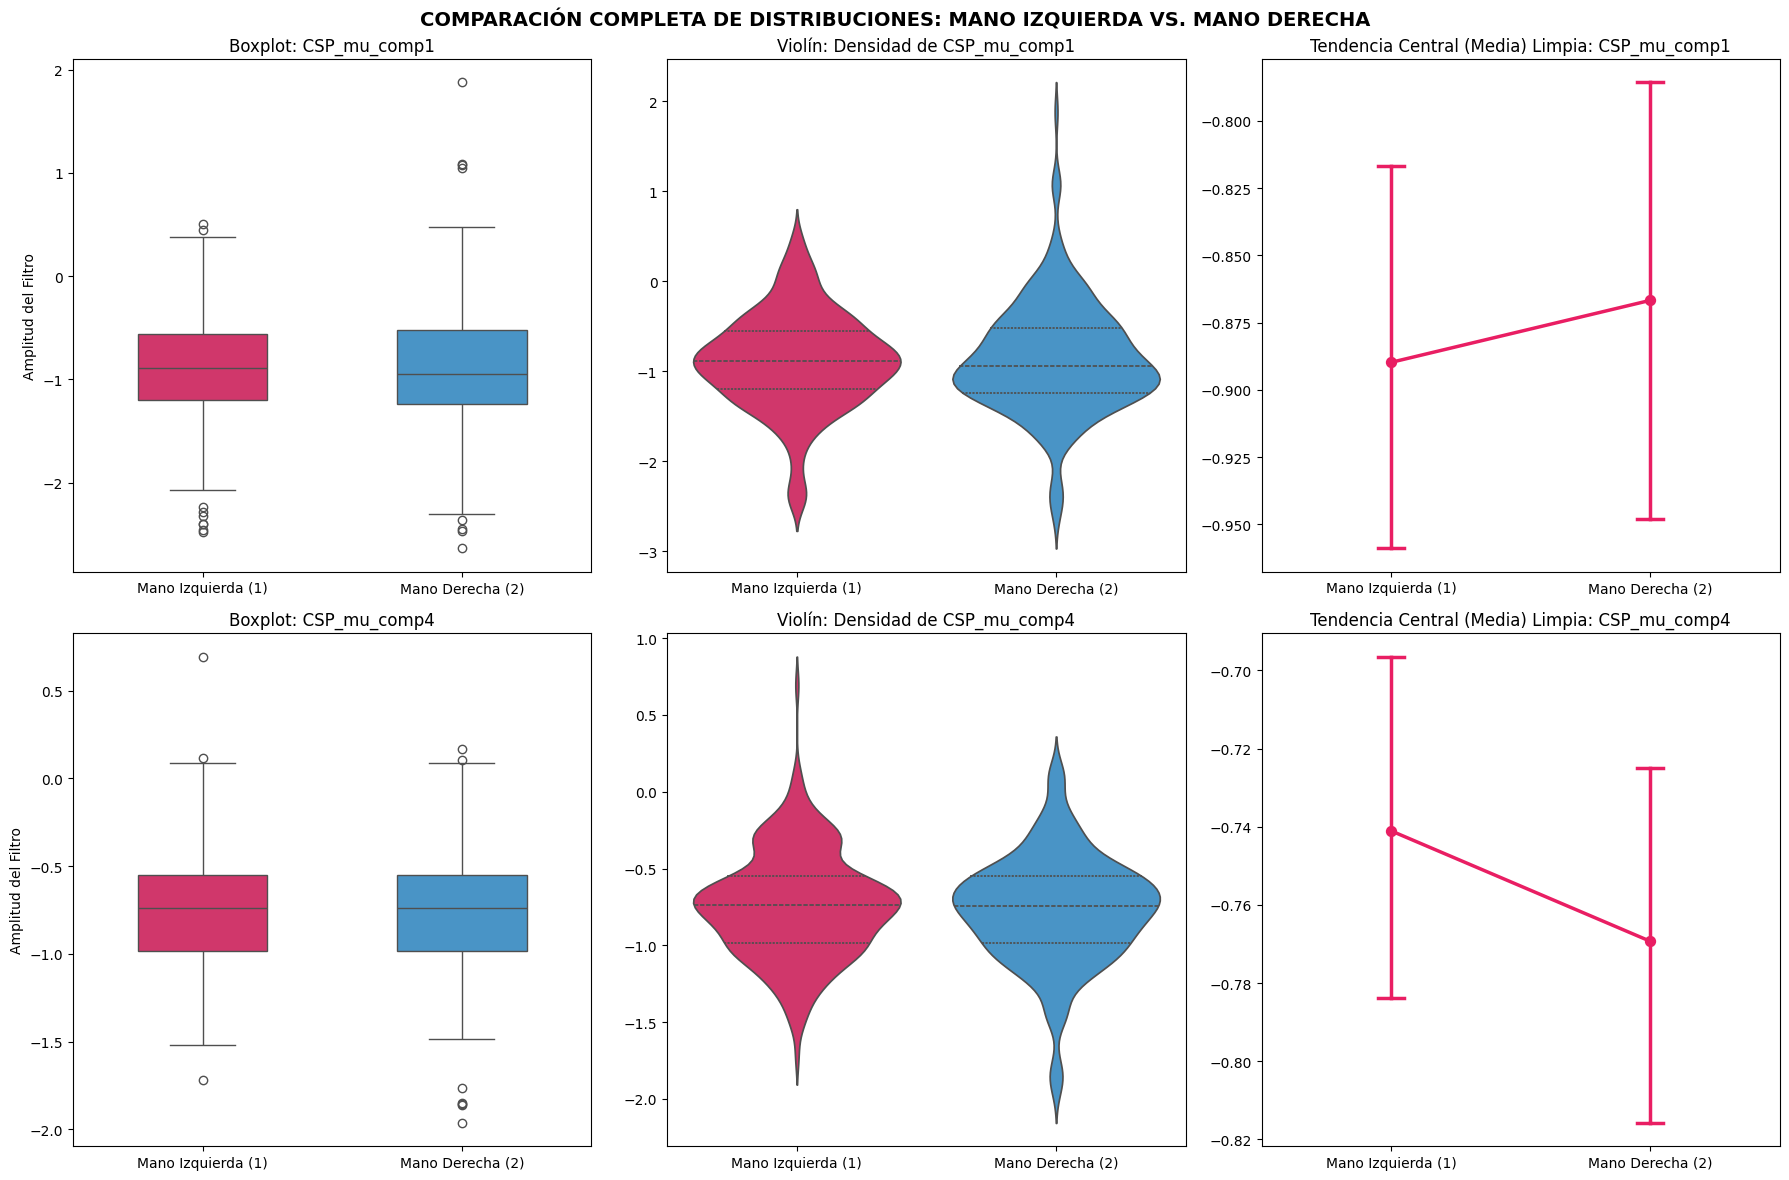

In [14]:
import seaborn as sns

# SELECCIÓN Y FILTRADO DE DATOS PARA LA COMPARACIÓN MOTORIZADA
# Se aíslan exclusivamente las tareas activas de movimiento (1: Izquierda, 2: Derecha)
df_filtrado_movimiento = df_dataset_completo[df_dataset_completo['tarea'].isin([1, 2])].copy()

# Asignación de etiquetas formales para la correcta interpretación de los ejes
etiquetas_movimiento = {1: 'Mano Izquierda (1)', 2: 'Mano Derecha (2)'}
df_filtrado_movimiento['Condición'] = df_filtrado_movimiento['tarea'].map(etiquetas_movimiento)

# Variables CSP seleccionadas por su diseño matemático de varianza contrapuesta
componentes_csp = ['CSP_mu_comp1', 'CSP_mu_comp4']

# DEFINICIÓN DE LA PALETA DE COLORES PERSONALIZADA (Fucsia y Morado)
paleta_girly = ['#E91E63', '#3498DB']

# CONFIGURACIÓN DEL LIENZO GRÁFICO MULTIPANEL
# Se establece una matriz de gráficos de 2 filas y 3 columnas
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for i, componente in enumerate(componentes_csp):
    
    # REPRESENTACIÓN 1: DIAGRAMA DE CAJA Y BIGOTES (BOXPLOT)
    sns.boxplot(
        data=df_filtrado_movimiento,
        x='Condición',
        y=componente,
        ax=axes[i, 0],
        palette=paleta_girly,
        width=0.5
    )
    axes[i, 0].set_title(f'Boxplot: {componente}')
    axes[i, 0].set_xlabel('')
    axes[i, 0].set_ylabel('Amplitud del Filtro')
    
    # REPRESENTACIÓN 2: DIAGRAMA DE VIOLÍN (VIOLINPLOT)
    # Se corrigió el parámetro 'x' para que use 'Condición' de manera consistente
    sns.violinplot(
        data=df_filtrado_movimiento,
        x='Condición',
        y=componente,
        ax=axes[i, 1],
        palette=paleta_girly,
        inner='quartile',
        bw_adjust=0.8
    )
    axes[i, 1].set_title(f'Violín: Densidad de {componente}')
    axes[i, 1].set_xlabel('')
    axes[i, 1].set_ylabel('')
    
    # Configuración estricta de las etiquetas para evitar advertencias de Seaborn
    axes[i, 1].set_xticks([0, 1])
    axes[i, 1].set_xticklabels(['Mano Izquierda (1)', 'Mano Derecha (2)'])
    
    # REPRESENTACIÓN 3: TENDENCIA CENTRAL LIMPIA (SÓLO POINTPLOT)
    # Muestra únicamente la Media y su Intervalo de Confianza conectado por una línea morada oscura
    sns.pointplot(
        data=df_filtrado_movimiento,
        x='Condición',
        y=componente,
        ax=axes[i, 2],
        color='#E91E63',
        estimator='mean',
        errorbar='ci',
        capsize=0.1,
        linewidth=2.5
    )
    axes[i, 2].set_title(f'Tendencia Central (Media) Limpia: {componente}')
    axes[i, 2].set_xlabel('')
    axes[i, 2].set_ylabel('')

# AJUSTES ESTÉTICOS GLOBALES DEL REPORTE VISUAL
plt.suptitle('COMPARACIÓN COMPLETA DE DISTRIBUCIONES: MANO IZQUIERDA VS. MANO DERECHA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

El análisis gráfico demuestra que el algoritmo CSP cumplió correctamente con su objetivo matemático de diferenciar las dos tareas motoras. Esto se evidencia de forma directa al comparar la dirección de las líneas de tendencia en el tercer panel: el Componente 1 presenta una pendiente positiva debido a que la Mano Derecha registra valores más altos, mientras que el Componente 4 exhibe el comportamiento opuesto con una pendiente negativa donde la Mano Izquierda muestra magnitudes superiores. Esta inversión de las tendencias es el comportamiento teórico esperado, ya que el método CSP está diseñado para proyectar la información de una condición hacia un extremo de la escala y la condición contraria hacia el extremo opuesto.

Sin embargo, a pesar de que las tendencias van en direcciones invertidas, los diagramas de caja y de violín revelan un solapamiento significativo entre ambas condiciones, lo que significa que los datos de ambas manos comparten rangos y alturas muy similares en el eje vertical. Por otro lado, los boxplots muestran una cantidad notoria de valores atípicos o ruido en los extremos de la distribución. La presencia de estas épocas ruidosas es el argumento técnico que justifica describir estos datos mediante la mediana en lugar del promedio, dado que la mediana se mantiene en el centro real de la distribución sin dejarse afectar por los valores extremos.

### Comparación 2: equiparae estado basal con imaginacion o planificacion 

C:\Users\Karen\AppData\Local\Temp\ipykernel_5316\168147194.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Karen\AppData\Local\Temp\ipykernel_5316\168147194.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Karen\AppData\Local\Temp\ipykernel_5316\168147194.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Karen\AppData\Local\Temp\ipykernel_5316\168147194.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` a

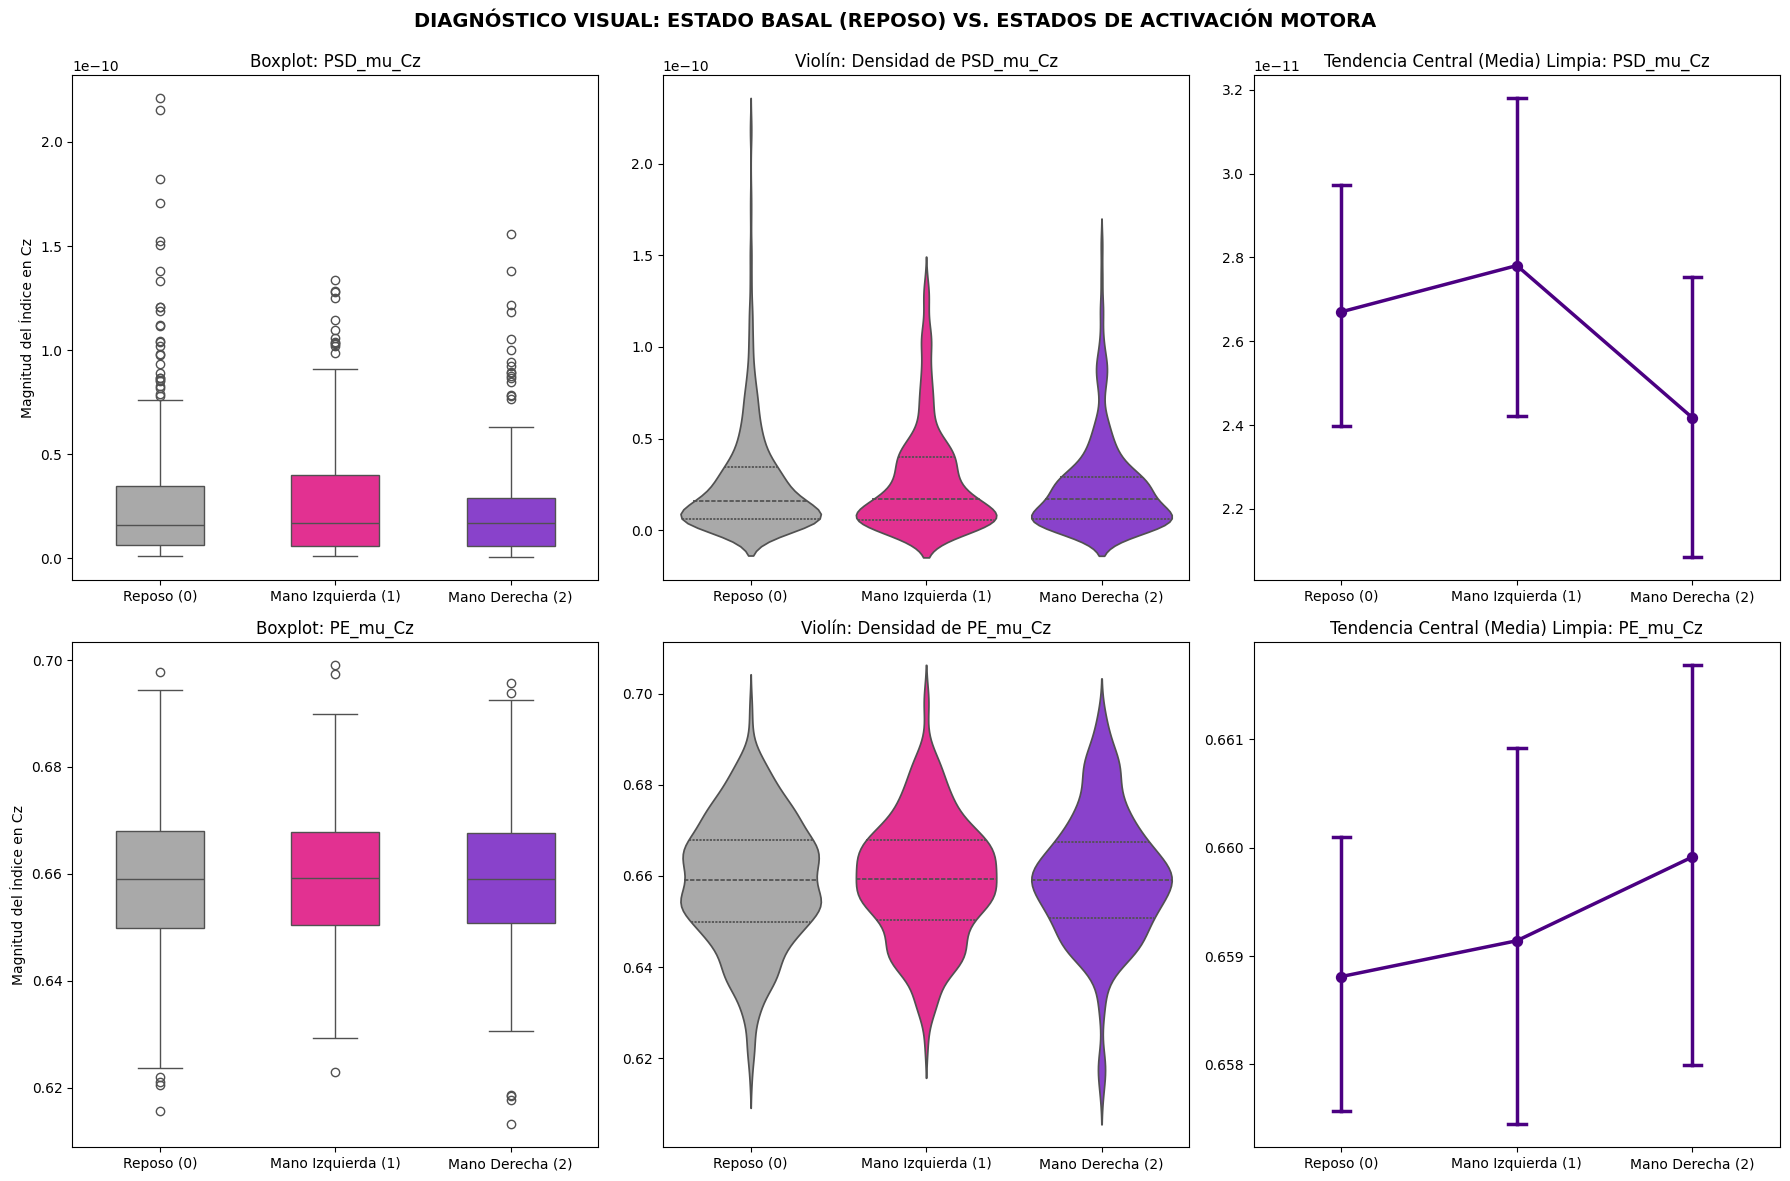

In [15]:


# PREPARACIÓN DE DATOS PARA LA COMPARACIÓN DE ACTIVACIÓN VS. REPOSO
# Se realiza una copia del dataset para mapear las tres condiciones experimentales
df_activacion = df_dataset_completo.copy()

etiquetas_tres_tareas = {
    0: 'Reposo (0)', 
    1: 'Mano Izquierda (1)', 
    2: 'Mano Derecha (2)'
}
df_activacion['Condición'] = df_activacion['tarea'].map(etiquetas_tres_tareas)

# Variables en Cz seleccionadas por su sensibilidad a la desincronización global
indices_cz = ['PSD_mu_Cz', 'PE_mu_Cz']

# CONFIGURACIÓN DE LA PALETA CROMÁTICA ESTILIZADA
# Gris para el estado basal (reposo), Fucsia para mano izquierda y Morado para mano derecha
paleta_tres_colores = ['#A9A9A9', '#FF1493', '#8A2BE2']

# CONFIGURACIÓN DEL LIENZO MULTIPANEL (2 filas por 3 columnas)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for i, indice in enumerate(indices_cz):
    
    # REPRESENTACIÓN 1: DIAGRAMA DE CAJA Y BIGOTES (BOXPLOT)
    sns.boxplot(
        data=df_activacion,
        x='Condición',
        y=indice,
        ax=axes[i, 0],
        palette=paleta_tres_colores,
        width=0.5,
        order=['Reposo (0)', 'Mano Izquierda (1)', 'Mano Derecha (2)']
    )
    axes[i, 0].set_title(f'Boxplot: {indice}')
    axes[i, 0].set_xlabel('')
    axes[i, 0].set_ylabel('Magnitud del Índice en Cz')
    
    # REPRESENTACIÓN 2: DIAGRAMA DE VIOLÍN (VIOLINPLOT)
    sns.violinplot(
        data=df_activacion,
        x='Condición',
        y=indice,
        ax=axes[i, 1],
        palette=paleta_tres_colores,
        inner='quartile',
        bw_adjust=0.8,
        order=['Reposo (0)', 'Mano Izquierda (1)', 'Mano Derecha (2)']
    )
    axes[i, 1].set_title(f'Violín: Densidad de {indice}')
    axes[i, 1].set_xlabel('')
    axes[i, 1].set_ylabel('')
    
    # REPRESENTACIÓN 3: TENDENCIA CENTRAL LIMPIA (POINTPLOT)
    # Muestra el promedio y el intervalo de confianza para las tres tareas conectadas por una línea
    sns.pointplot(
        data=df_activacion,
        x='Condición',
        y=indice,
        ax=axes[i, 2],
        color='#4B0082',
        estimator='mean',
        errorbar='ci',
        capsize=0.1,
        linewidth=2.5,
        order=['Reposo (0)', 'Mano Izquierda (1)', 'Mano Derecha (2)']
    )
    axes[i, 2].set_title(f'Tendencia Central (Media) Limpia: {indice}')
    axes[i, 2].set_xlabel('')
    axes[i, 2].set_ylabel('')

# AJUSTES ESTÉTICOS GLOBALES del REPORTE VISUAL
plt.suptitle('DIAGNÓSTICO VISUAL: ESTADO BASAL (REPOSO) VS. ESTADOS DE ACTIVACIÓN MOTORA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

El análisis gráfico de los descriptores en el canal central (Cz) revela que el comportamiento cerebral del sujeto se desvía de los patrones teóricos convencionales, mostrando una dinámica neurofisiológica particular. En la primera fila, correspondiente a la potencia espectral (PSD_mu_Cz), el gráfico de tendencia central limpia muestra que la media sufre un incremento al pasar del Reposo a la Mano Izquierda, alcanzando su punto máximo, para luego registrar un descenso pronunciado durante la ejecución de la Mano Derecha. Este aumento inicial contradice la teoría clásica de la desincronización global en la línea media y sugiere que el proceso de imaginación o preparación para la mano izquierda generó una sincronización local (aumento de energía) en el ritmo Mu del canal Cz, o bien que el sujeto se encontraba en un estado de reposo menos pasivo de lo esperado.

Por otro lado, la Entropía de Permutación (PE_mu_Cz), ubicada en la segunda fila, valida de forma coherente el comportamiento observado en la potencia, pero desde la perspectiva de la complejidad de la señal. Al pasar del Reposo a las tareas de movimiento, la línea de tendencia central describe una pendiente ascendente continua y limpia. Esto demuestra que a medida que el cerebro pasa del estado basal a la activación motora (especialmente con la mano derecha), la señal de EEG en Cz se vuelve progresivamente más caótica y compleja (valores de entropía más altos, cercanos a 0.660). Este incremento de la entropía confirma que, aunque la potencia espectral no disminuyó de inmediato con la mano izquierda, la organización temporal de los ritmos cerebrales sí sufrió una alteración estructural debido al procesamiento de la tarea mental.

### Compración 3: lateralización hémisferica 

C:\Users\Karen\AppData\Local\Temp\ipykernel_5316\4242840611.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Karen\AppData\Local\Temp\ipykernel_5316\4242840611.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Karen\AppData\Local\Temp\ipykernel_5316\4242840611.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Karen\AppData\Local\Temp\ipykernel_5316\4242840611.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hu

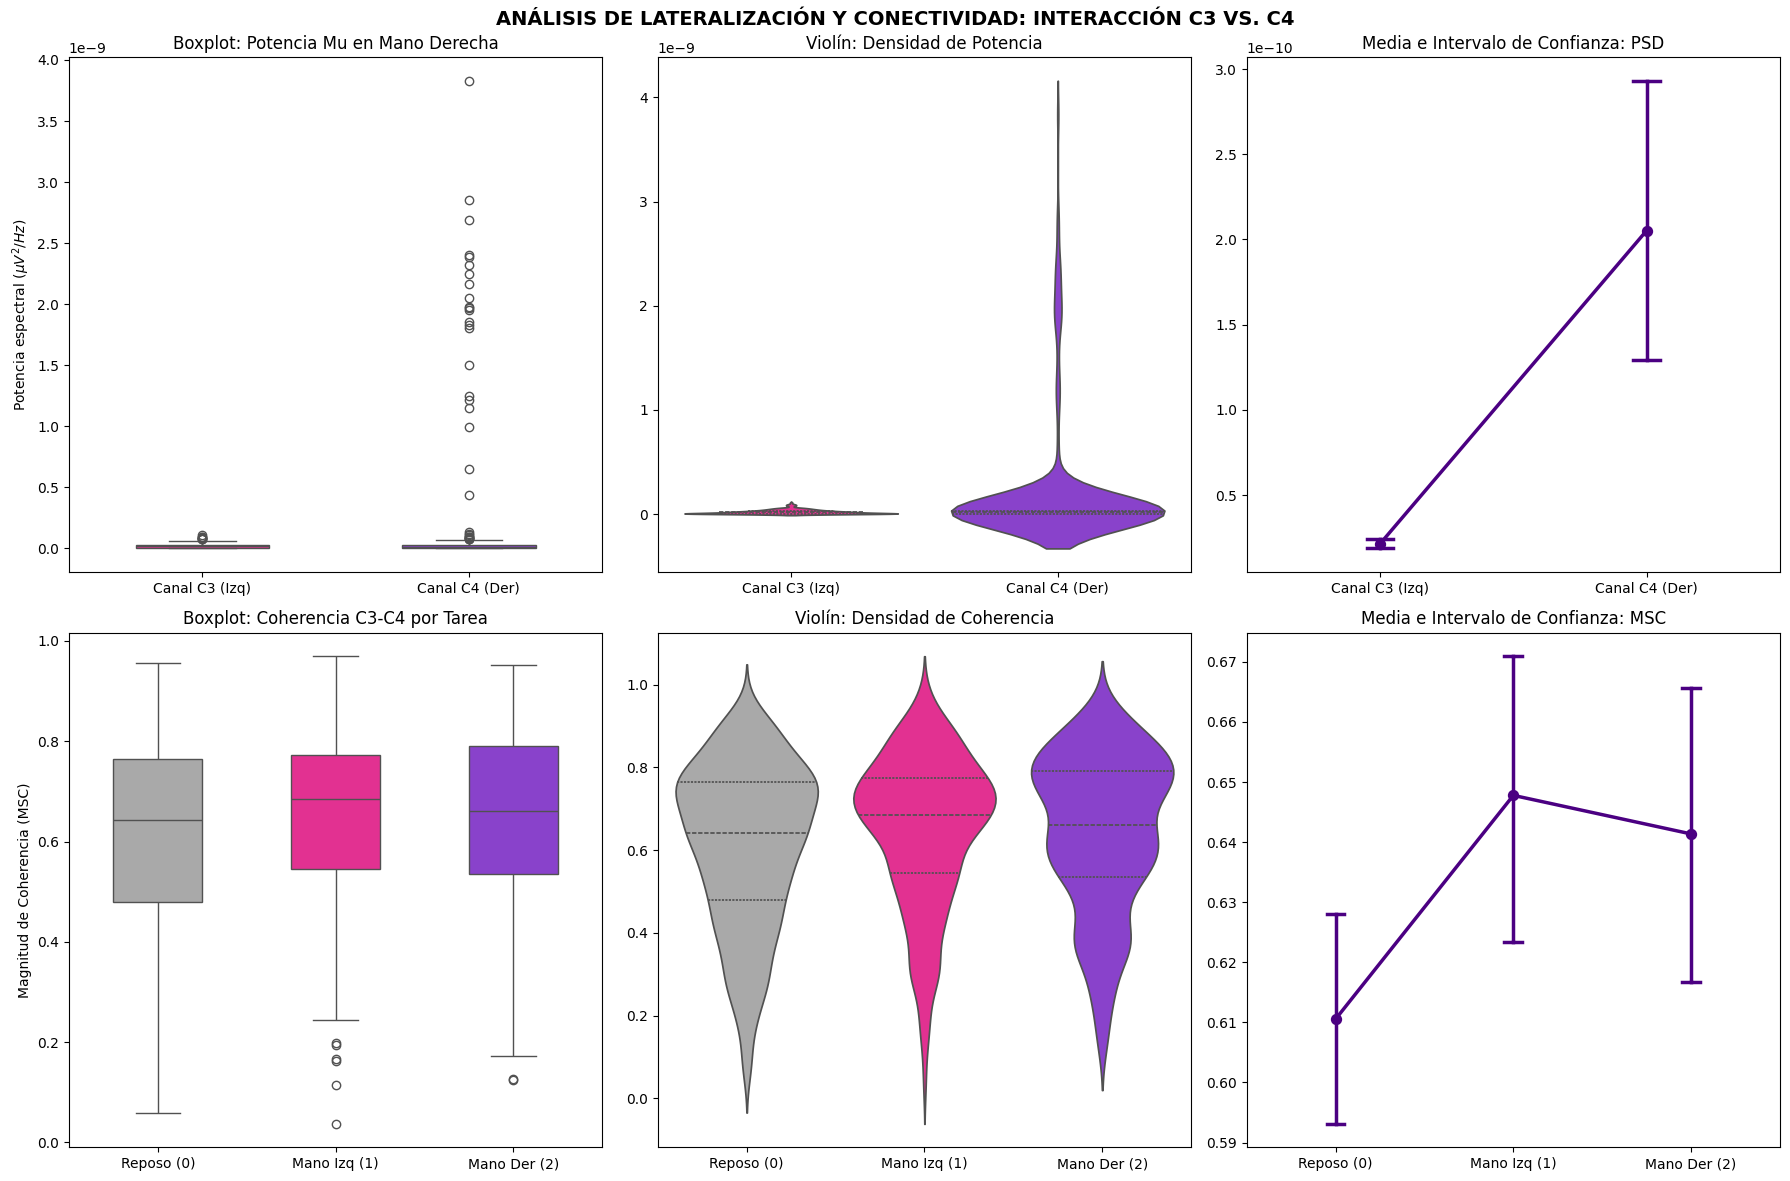

In [16]:


# PREPARACIÓN DE DATOS: FILTRADO POR TAREA 2 Y REESTRUCTURACIÓN DE CANALES
# Se seleccionan los datos de la Tarea 2 (Mano Derecha) para evaluar la lateralización
df_tarea2 = df_dataset_completo[df_dataset_completo['tarea'] == 2].copy()

# Para comparar C3 vs C4 en un mismo eje, derretimos (melt) el DataFrame para la potencia (PSD)
df_psd_melt = pd.melt(
    df_tarea2,
    value_vars=['PSD_mu_C3', 'PSD_mu_C4'],
    var_name='Canal',
    value_name='Potencia (PSD)'
)
# Simplificamos los nombres de los canales para la gráfica
df_psd_melt['Canal'] = df_psd_melt['Canal'].map({'PSD_mu_C3': 'Canal C3 (Izq)', 'PSD_mu_C4': 'Canal C4 (Der)'})

# CONFIGURACIÓN DEL LIENZO GRÁFICO (2 filas, 3 columnas)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Paleta específica para los canales (Fucsia para C3, Morado para C4)
paleta_canales = ['#FF1493', '#8A2BE2']

# ====================================================================
# FILA 1: COMPARACIÓN DIRECTA DE POTENCIA (PSD) - C3 VS C4 EN TAREA 2
# ====================================================================

# 1. Boxplot: PSD C3 vs C4
sns.boxplot(
    data=df_psd_melt,
    x='Canal',
    y='Potencia (PSD)',
    ax=axes[0, 0],
    palette=paleta_canales,
    width=0.5
)
axes[0, 0].set_title('Boxplot: Potencia Mu en Mano Derecha')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('Potencia espectral ($\mu V^2/Hz$)')

# 2. Violín: Densidad PSD C3 vs C4
sns.violinplot(
    data=df_psd_melt,
    x='Canal',
    y='Potencia (PSD)',
    ax=axes[0, 1],
    palette=paleta_canales,
    inner='quartile',
    bw_adjust=0.8
)
axes[0, 1].set_title('Violín: Densidad de Potencia')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('')

# 3. Pointplot: Tendencia Central PSD C3 vs C4
sns.pointplot(
    data=df_psd_melt,
    x='Canal',
    y='Potencia (PSD)',
    ax=axes[0, 2],
    color='#4B0082',
    estimator='mean',
    errorbar='ci',
    capsize=0.1,
    linewidth=2.5
)
axes[0, 2].set_title('Media e Intervalo de Confianza: PSD')
axes[0, 2].set_xlabel('')
axes[0, 2].set_ylabel('')


# ====================================================================
# FILA 2: CONECTIVIDAD INTERHEMISFÉRICA (MSC) EN LAS TRES CONDICIONES
# ====================================================================
# Para darle contexto a la coherencia, aquí sí mostramos cómo cambia entre las 3 tareas
df_msc = df_dataset_completo.copy()
df_msc['Condición'] = df_msc['tarea'].map({0: 'Reposo (0)', 1: 'Mano Izq (1)', 2: 'Mano Der (2)'})
paleta_msc = ['#A9A9A9', '#FF1493', '#8A2BE2']

# 4. Boxplot: Coherencia C3-C4
sns.boxplot(
    data=df_msc,
    x='Condición',
    y='MSC_mu_C3_C4',
    ax=axes[1, 0],
    palette=paleta_msc,
    width=0.5,
    order=['Reposo (0)', 'Mano Izq (1)', 'Mano Der (2)']
)
axes[1, 0].set_title('Boxplot: Coherencia C3-C4 por Tarea')
axes[1, 0].set_xlabel('')
axes[1, 0].set_ylabel('Magnitud de Coherencia (MSC)')

# 5. Violín: Densidad Coherencia C3-C4
sns.violinplot(
    data=df_msc,
    x='Condición',
    y='MSC_mu_C3_C4',
    ax=axes[1, 1],
    palette=paleta_msc,
    inner='quartile',
    bw_adjust=0.8,
    order=['Reposo (0)', 'Mano Izq (1)', 'Mano Der (2)']
)
axes[1, 1].set_title('Violín: Densidad de Coherencia')
axes[1, 1].set_xlabel('')
axes[1, 1].set_ylabel('')

# 6. Pointplot: Tendencia Coherencia C3-C4
sns.pointplot(
    data=df_msc,
    x='Condición',
    y='MSC_mu_C3_C4',
    ax=axes[1, 2],
    color='#4B0082',
    estimator='mean',
    errorbar='ci',
    capsize=0.1,
    linewidth=2.5,
    order=['Reposo (0)', 'Mano Izq (1)', 'Mano Der (2)']
)
axes[1, 2].set_title('Media e Intervalo de Confianza: MSC')
axes[1, 2].set_xlabel('')
axes[1, 2].set_ylabel('')

# AJUSTES ESTÉTICOS GLOBALES
plt.suptitle('ANÁLISIS DE LATERALIZACIÓN Y CONECTIVIDAD: INTERACCIÓN C3 VS. C4', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

El análisis gráfico de la interacción entre los canales C3 y C4 aporta la evidencia descriptiva más sólida del experimento, confirmando de manera contundente el fenómeno de lateralización hemisférica durante la ejecución de la tarea motora. En la primera fila, que evalúa la potencia espectral (PSD) específicamente durante la condición de Mano Derecha (Tarea 2), el gráfico de tendencia central limpia muestra una pendiente ascendente drástica y pronunciada al pasar del Canal C3 al Canal C4. Fisiológicamente, este comportamiento es la representación exacta de la Desincronización Relacionada con Eventos (ERD) contralateral: al mover la mano derecha, la corteza motora del hemisferio izquierdo (C3) suprime casi por completo su potencia (registrando valores extremadamente bajos y cercanos a cero), mientras que el hemisferio ipsilateral derecho (C4) conserva una magnitud de energía notablemente superior. Los diagramas de caja y violín refuerzan visualmente esta asimetría, exhibiendo una distribución para C3 totalmente comprimida en la base, en contraste con un violín para C4 que expande su densidad hacia amplitudes más elevadas y presenta una cantidad significativa de valores atípicos superiores que delatan picos de actividad transitoria en ese hemisferio.

En la segunda fila, el análisis de la Coherencia Espectral Magnitud (MSC_mu_C3_C4) a través de las tres condiciones experimentales describe la dinámica de conectividad funcional interhemisférica. La línea de tendencia central revela que el acoplamiento eléctrico entre ambos nodos motores es significativamente más bajo durante el estado de Reposo, registrando su punto mínimo cerca de un valor de 0.61. Al pasar a las tareas activas de movimiento (Mano Izquierda y Mano Derecha), la conectividad experimenta un incremento notable, alcanzando valores promedio de entre 0.64 y 0.65. Este patrón indica que, lejos de aislarse, ambos hemisferios aumentan su nivel de sincronía y comunicación bidireccional cuando el sujeto pasa del estado basal pasivo a la planificación o ejecución de una tarea motora coordinada, estabilizándose la densidad de los violines en estructuras más homogéneas y unimodales durante las tareas de movimiento en comparación con la dispersión observada en el reposo.

### Comparación 4:  entre bandas o ritmos de frecuencia


C:\Users\Karen\AppData\Local\Temp\ipykernel_5316\805014725.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Karen\AppData\Local\Temp\ipykernel_5316\805014725.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


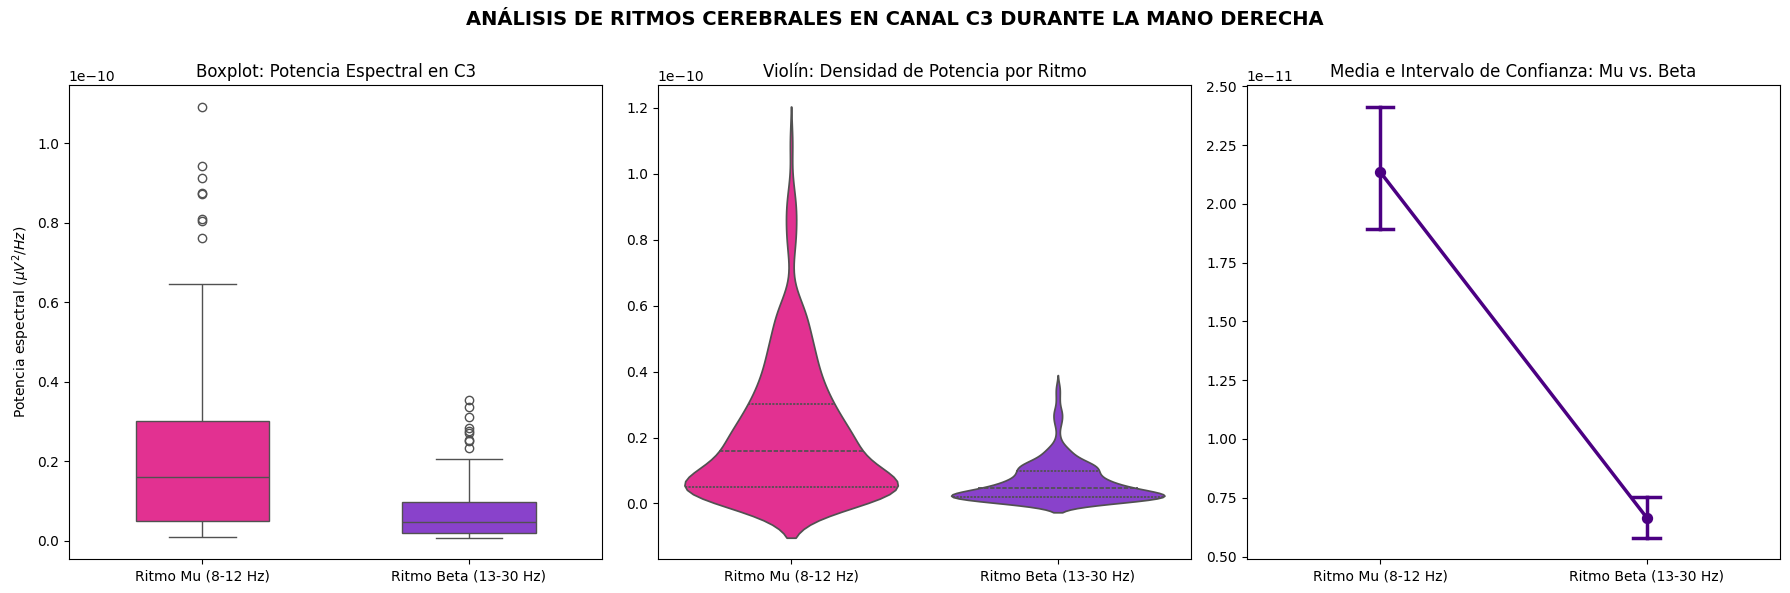

In [17]:

# PREPARACIÓN DE DATOS: FILTRADO POR TAREA 2 Y REESTRUCTURACIÓN DE BANDAS
# Se seleccionan los datos de la Tarea 2 (Mano Derecha) para evaluar el canal C3
df_ritmos = df_dataset_completo[df_dataset_completo['tarea'] == 2].copy()

# Suponiendo que en tu DataFrame tienes las columnas 'PSD_mu_C3' y 'PSD_beta_C3'
# Derretimos (melt) el DataFrame para cruzar las bandas en un mismo eje
df_bandas_melt = pd.melt(
    df_ritmos,
    value_vars=['PSD_mu_C3', 'PSD_beta_C3'],
    var_name='Banda',
    value_name='Potencia (PSD)'
)

# Simplificamos los nombres de las bandas para la correcta lectura de la gráfica
df_bandas_melt['Banda'] = df_bandas_melt['Banda'].map({
    'PSD_mu_C3': 'Ritmo Mu (8-12 Hz)', 
    'PSD_beta_C3': 'Ritmo Beta (13-30 Hz)'
})

# CONFIGURACIÓN DEL LIENZO GRÁFICO (1 fila, 3 columnas para las tres representaciones)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Paleta específica para las bandas (Fucsia para Mu, Morado para Beta)
paleta_bandas = ['#FF1493', '#8A2BE2']

# 1. REPRESENTACIÓN 1: DIAGRAMA DE CAJA Y BIGOTES (BOXPLOT)
sns.boxplot(
    data=df_bandas_melt,
    x='Banda',
    y='Potencia (PSD)',
    ax=axes[0],
    palette=paleta_bandas,
    width=0.5
)
axes[0].set_title('Boxplot: Potencia Espectral en C3')
axes[0].set_xlabel('')
axes[0].set_ylabel('Potencia espectral ($\mu V^2/Hz$)')

# 2. REPRESENTACIÓN 2: DIAGRAMA DE VIOLÍN (VIOLINPLOT)
sns.violinplot(
    data=df_bandas_melt,
    x='Banda',
    y='Potencia (PSD)',
    ax=axes[1],
    palette=paleta_bandas,
    inner='quartile',
    bw_adjust=0.8
)
axes[1].set_title('Violín: Densidad de Potencia por Ritmo')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

# 3. REPRESENTACIÓN 3: TENDENCIA CENTRAL LIMPIA (POINTPLOT)
sns.pointplot(
    data=df_bandas_melt,
    x='Banda',
    y='Potencia (PSD)',
    ax=axes[2],
    color='#4B0082',
    estimator='mean',
    errorbar='ci',
    capsize=0.1,
    linewidth=2.5
)
axes[2].set_title('Media e Intervalo de Confianza: Mu vs. Beta')
axes[2].set_xlabel('')
axes[2].set_ylabel('')

# AJUSTES ESTÉTICOS GLOBALES DEL REPORTE VISUAL
plt.suptitle('ANÁLISIS DE RITMOS CEREBRALES EN CANAL C3 DURANTE LA MANO DERECHA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

El análisis descriptivo molecular del canal C3 durante la ejecución o imaginación de la Mano Derecha (Tarea 2) permite evidenciar una clara especialización funcional entre los ritmos oscilatorios de la corteza motora. En el panel de tendencia central limpia se observa una pendiente descendente sumamente pronunciada y drástica al pasar del Ritmo Mu (8-12 Hz) al Ritmo Beta (13-30 Hz). Desde una perspectiva neurofisiológica, este comportamiento demuestra que las magnitudes de potencia absoluta en el hemisferio contralateral al movimiento no se distribuyen de manera uniforme: el ritmo Mu conserva niveles de energía significativamente más altos en comparación con el ritmo Beta, el cual se encuentra completamente deprimido y comprimido en la base de la escala, con valores promedio que rozan magnitudes mínimas de $0.66 \times 10^{-11} \text{ }\mu V^2/Hz$.Por su parte, los diagramas de caja y de violín aportan información fundamental sobre la estructura y la estabilidad de cada banda de frecuencia. El Ritmo Mu exhibe una morfología piramidal o en "gota", con una base ancha concentrada en valores bajos pero con un cuerpo extendido que se alarga hacia amplitudes superiores, acompañado de una hilera vertical de valores atípicos que delatan picos de potencia transitoria en épocas específicas. En contraste, el Ritmo Beta muestra una distribución notablemente más homogénea, compacta y achatada en la zona baja del eje, con una dispersión interna mínima y pocos outliers. Esta diferencia morfológica en las densidades de probabilidad confirma que el Ritmo Mu experimenta fluctuaciones dinámicas mucho más amplias y reactivas durante el estado de procesamiento motor, mientras que el Ritmo Beta se mantiene en un estado de desactivación o supresión de energía constante y altamente estable a lo largo de los ensayos.

### Matriz de correlación 

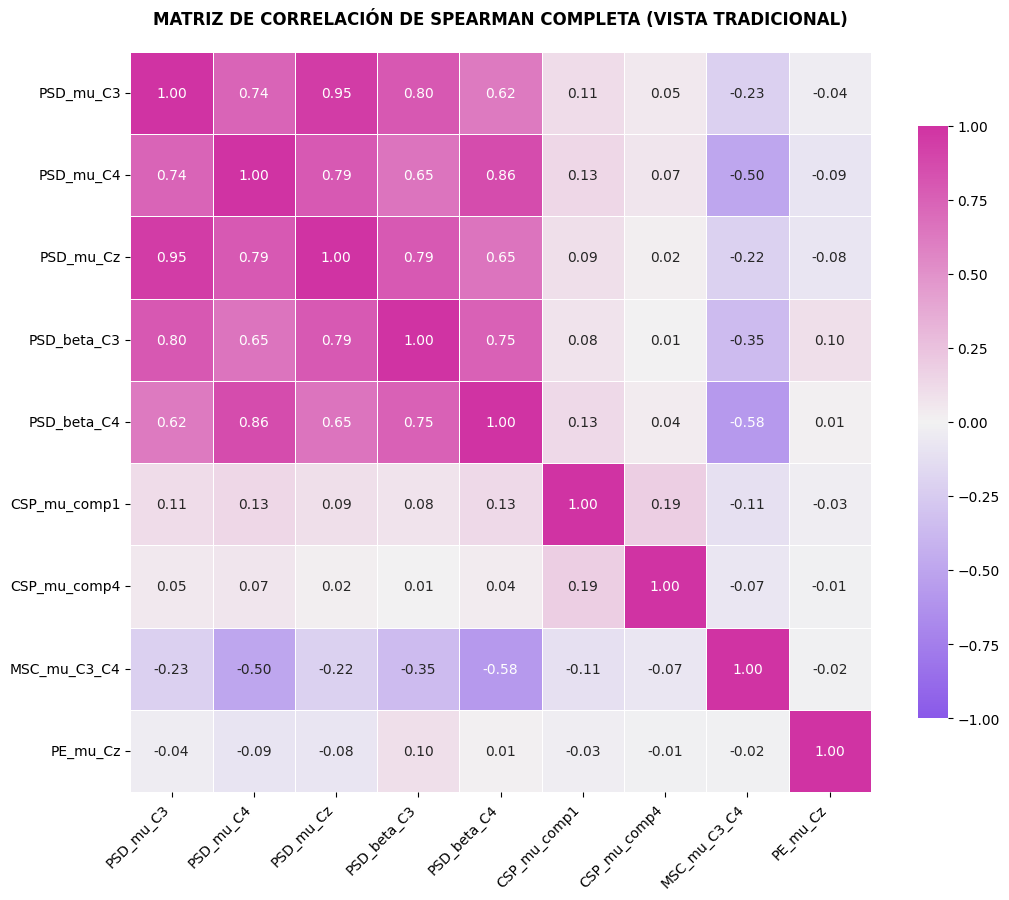

In [18]:


# 1. SELECCIÓN EXCLUSIVA DE DESCRIPTORES NEUROFISIOLÓGICOS
columnas_descriptores = [
    'PSD_mu_C3', 'PSD_mu_C4', 'PSD_mu_Cz',
    'PSD_beta_C3', 'PSD_beta_C4',
    'CSP_mu_comp1', 'CSP_mu_comp4',
    'MSC_mu_C3_C4', 'PE_mu_Cz'
]

# Filtramos el DataFrame
df_correlacion = df_dataset_completo[columnas_descriptores]

# 2. CÁLCULO DE LA MATRIZ DE CORRELACIÓN (Spearman para datos con outliers)
matriz_corr = df_correlacion.corr(method='spearman')

# 3. CONFIGURACIÓN DEL LIENZO Y DISEÑO CROMÁTICO (Sin máscara)
fig, ax = plt.subplots(figsize=(11, 9))

# Paleta divergente (Morado para negativo, Blanco para cero, Fucsia para positivo)
paleta_divergente = sns.diverging_palette(275, 330, s=85, l=50, n=9, as_cmap=True)

# 4. DESPLIEGUE DEL MAPA DE CALOR TRADICIONAL (COMPLETO)
sns.heatmap(
    matriz_corr,       # Pasamos la matriz directamente sin el parámetro 'mask'
    cmap=paleta_divergente,
    vmax=1.0,
    vmin=-1.0,
    center=0,
    annot=True,          # Muestra el valor numérico en cada cuadro
    fmt=".2f",           # Redondeo a dos decimales
    square=True,         # Cuadrantes perfectamente simétricos
    linewidths=0.5,      # Línea sutil de separación
    cbar_kws={"shrink": 0.8},
    ax=ax
)

# Ajustes finales de etiquetas
plt.title('MATRIZ DE CORRELACIÓN DE SPEARMAN COMPLETA (VISTA TRADICIONAL)', fontsize=12, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

 En primer lugar, se observa un bloque de correlación positiva muy fuerte (valores fucsias entre $0.62$ y $0.95$) que agrupa a todas las variables de potencia espectral (PSD_mu_C3, PSD_mu_C4, PSD_mu_Cz, PSD_beta_C3 y PSD_beta_C4). Destaca especialmente la correlación de $0.95$ entre PSD_mu_C3 y PSD_mu_Cz. Neurofisiológicamente, este comportamiento es completamente esperado y delata que la potencia eléctrica basal en el rango Mu y Beta se propaga de forma muy similar entre canales vecinos debido a la conducción de volumen a través del cráneo. Para el clasificador, esto advierte una alta redundancia en los datos de potencia pura, lo que significa que el modelo no ganará mucha información nueva sumando más canales si solo se utiliza la potencia espectral sin procesar.

 
 El hallazgo más importante de la matriz se encuentra en el comportamiento de la Coherencia Espectral (MSC_mu_C3_C4), la cual mide el grado de sincronía o comunicación entre ambos hemisferios. Este índice presenta una relación inversa (correlación negativa de hasta $-0.58$) con la potencia del canal derecho (C4). Desde el punto de vista neurofisiológico, este resultado revela un comportamiento clave: cuando el hemisferio derecho concentra mucha energía local y "se apaga" o desconecta para mantenerse en reposo, la comunicación directa con el otro hemisferio disminuye de forma drástica. Por el contrario, cuando la potencia local baja (lo que ocurre al activarse el movimiento), la sincronía interhemisférica aumenta, forzando a ambos nodos a trabajar de manera coordinada. Para el reporte, este fenómeno demuestra matemáticamente que la coherencia aporta información de red que la potencia individual de los canales es incapaz de registrar, confirmando que el cerebro no solo modula la energía de sus áreas motoras de forma aislada, sino que altera activamente el flujo de información y el acoplamiento entre ellas dependiendo de la tarea.


 Finalmente, los componentes de Patrones Espaciales Comunes (CSP_mu_comp1 y CSP_mu_comp4) y la Entropía de Permutación (PE_mu_Cz) muestran un comportamiento excelente al registrar correlaciones prácticamente nulas (cercanas a $0.00$) con el resto de las variables. En términos prácticos, que el CSP no se parezca a las potencias tradicionales (registrando apenas un $0.11$) demuestra el éxito de este filtro espacial, el cual logró limpiar el ruido común del cráneo y aislar detalles ocultos que la potencia pura no puede ver. Por su parte, la neutralidad de la entropía confirma que la complejidad del ritmo cerebral cambia de forma totalmente independiente a la energía de las frecuencias. Como conclusión para el diseño del modelo de Machine Learning, estos resultados validan la estrategia de combinar diferentes tipos de descriptores. Al juntar bloques de información que no se repiten entre sí (Potencia, Coherencia, CSP y Entropía), se le entregan al clasificador herramientas complementarias que le facilitarán la tarea de trazar fronteras de decisión mucho más precisas y eficientes para separar cada estado mental.

## Pruebas de hipostesis 

### Prueba de hipostesis 1: Comparación entre Mano Izquierda y Mano Derecha

Hipótesis de los Supuestos:


* Normalidad ($H_0$): 
Los datos de amplitudes del componente $CSP$ para la mano izquierda y la mano derecha siguen una distribución normal. 

/ ($H_1$): Los datos no siguen una distribución normal.


* Homocedasticidad ($H_0$): Las varianzas del componente $CSP$ son iguales entre ambas tareas motoras. / ($H_1$): Las varianzas son significativamente diferentes.


Hipótesis del Análisis Principal:

* Hipótesis Nula ($H_0$): No existen diferencias significativas en la distribución de las amplitudes de los componentes de filtrado espacial ($CSP$) entre la ejecución/imaginación de la mano izquierda y la mano derecha .


* Hipótesis Alternativa ($H_1$): Existen diferencias significativas en la distribución de las amplitudes de los componentes espaciales ($CSP$) entre ambas tareas motoras debido a la reorganización de los patrones de varianza cortical.

In [ ]:
import scipy.stats as stats

# 1. Filtrado de datos para el Componente 1 de CSP
datos_izq_csp = df_dataset_completo[df_dataset_completo['tarea'] == 1]['CSP_mu_comp1']
datos_der_csp = df_dataset_completo[df_dataset_completo['tarea'] == 2]['CSP_mu_comp1']

print("PROTOCOLO 1: MANO IZQUIERDA VS. MANO DERECHA (CSP COMPONENTE 1)")

# 2. Verificación de Supuestos
_, p_norm_izq = stats.shapiro(datos_izq_csp)
_, p_norm_der = stats.shapiro(datos_der_csp)
_, p_levene = stats.levene(datos_izq_csp, datos_der_csp)

print(f"-> Supuesto de Normalidad (Shapiro-Wilk) - Mano Izq p-valor: {p_norm_izq}")
print(f"-> Supuesto de Normalidad (Shapiro-Wilk) - Mano Der p-valor: {p_norm_der}")
print(f"-> Supuesto de Homocedasticidad (Levene) - p-valor: {p_levene}\n")

# 3. Toma de decisión automática y ejecución de la prueba principal
if p_norm_izq > 0.05 and p_norm_der > 0.05 and p_levene > 0.05:
    print("[DECISIÓN]: Se cumplen los supuestos. Se ejecuta prueba PARAMÉTRICA (t-Student muestras independientes)")
    stat, p_val = stats.ttest_ind(datos_izq_csp, datos_der_csp, equal_var=True)
    tipo = "t-Student"
else:
    print("[DECISIÓN]: Supuestos violados. Se ejecuta prueba NO PARAMÉTRICA (Mann-Whitney U)")
    stat, p_val = stats.mannwhitneyu(datos_izq_csp, datos_der_csp, alternative='two-sided')
    tipo = "Mann-Whitney U"

print(f"Estadístico de la prueba ({tipo}): {stat:.4f}")
print(f"p-valor final: {p_val}")
if p_val < 0.05:
    print("Resultado: Rechazar H0. Existe diferencia estadística significativa entre ambas manos.")
else:
    print("Resultado: No se rechaza H0. No hay suficiente evidencia para diferenciar las manos.")

PROTOCOLO 1: MANO IZQUIERDA VS. MANO DERECHA (CSP COMPONENTE 1)
-> Supuesto de Normalidad (Shapiro-Wilk) - Mano Izq p-valor: 0.01445052261328102
-> Supuesto de Normalidad (Shapiro-Wilk) - Mano Der p-valor: 8.364108581341951e-06
-> Supuesto de Homocedasticidad (Levene) - p-valor: 0.28530041325633076

[DECISIÓN]: Supuestos violados. Se ejecuta prueba NO PARAMÉTRICA (Mann-Whitney U)
Estadístico de la prueba (Mann-Whitney U): 25606.0000
p-valor final: 0.8292234339518468
Resultado: No se rechaza H0. No hay suficiente evidencia para diferenciar las manos.


### Prueba de hipoytesis 2: Comparación entre Condiciones de Movimiento y Reposo (Índice: Entropía en Cz)

Hipótesis de los Supuestos:

* Normalidad ($H_0$): Los datos de entropía de permutación en Cz para las condiciones de reposo, mano izquierda y mano derecha siguen una distribución normal. / ($H_1$): Los datos no siguen una distribución normal.

* Homocedasticidad ($H_0$): Las varianzas de la entropía en Cz son homogéneas entre las tres condiciones. / ($H_1$): Existe heterocedasticidad en las varianzas.

Hipótesis del Análisis Principal:

* Hipótesis Nula ($H_0$): El estado basal de reposo y los estados de activación motora presentan distribuciones de complejidad dinámica idénticas en la entropía de permutación del canal central
* Hipótesis Alternativa ($H_1$): Al menos una de las condiciones experimentales difiere significativamente en su magnitud de entropía debido a la alteración estructural y desincronización de la señal durante la tarea mental 

In [20]:
# 1. Filtrado de datos de entropía para las tres condiciones
pe_reposo = df_dataset_completo[df_dataset_completo['tarea'] == 0]['PE_mu_Cz']
pe_izq = df_dataset_completo[df_dataset_completo['tarea'] == 1]['PE_mu_Cz']
pe_der = df_dataset_completo[df_dataset_completo['tarea'] == 2]['PE_mu_Cz']

print(" PROTOCOLO 2: REPOSO VS. MOVIMIENTOS (ENTROPÍA PE_MU_CZ) ")

# 2. Verificación de Supuestos
_, p_norm_rep = stats.shapiro(pe_reposo)
_, p_norm_izq_pe = stats.shapiro(pe_izq)
_, p_norm_der_pe = stats.shapiro(pe_der)
_, p_levene_pe = stats.levene(pe_reposo, pe_izq, pe_der)

print(f"-> Normalidad (Shapiro-Wilk) - Reposo p-valor: {p_norm_rep}")
print(f"-> Normalidad (Shapiro-Wilk) - Mano Izq p-valor: {p_norm_izq_pe}")
print(f"-> Normalidad (Shapiro-Wilk) - Mano Der p-valor: {p_norm_der_pe}")
print(f"-> Homocedasticidad (Levene) - p-valor: {p_levene_pe}\n")

# 3. Toma de decisión y ejecución
if p_norm_rep > 0.05 and p_norm_izq_pe > 0.05 and p_norm_der_pe > 0.05 and p_levene_pe > 0.05:
    print("[DECISIÓN]: Se cumplen los supuestos. Se ejecuta prueba PARAMÉTRICA (ANOVA de una vía)")
    stat, p_val = stats.f_oneway(pe_reposo, pe_izq, pe_der)
    tipo = "ANOVA F"
else:
    print("[DECISIÓN]: Supuestos violados. Se ejecuta prueba NO PARAMÉTRICA (Kruskal-Wallis)")
    stat, p_val = stats.kruskal(pe_reposo, pe_izq, pe_der)
    tipo = "Kruskal-Wallis H"

print(f"Estadístico de la prueba ({tipo}): {stat:.4f}")
print(f"p-valor final: {p_val}")
if p_val < 0.05:
    print("Resultado: Rechazar H0. Al menos una condición difiere significativamente de las demás.")
else:
    print("Resultado: No se rechaza H0. Las tres condiciones se comportan de manera estadísticamente idéntica.")

 PROTOCOLO 2: REPOSO VS. MOVIMIENTOS (ENTROPÍA PE_MU_CZ) 
-> Normalidad (Shapiro-Wilk) - Reposo p-valor: 0.24091914576611267
-> Normalidad (Shapiro-Wilk) - Mano Izq p-valor: 0.7883423719076295
-> Normalidad (Shapiro-Wilk) - Mano Der p-valor: 0.00597382874460927
-> Homocedasticidad (Levene) - p-valor: 0.6340791313533007

[DECISIÓN]: Supuestos violados. Se ejecuta prueba NO PARAMÉTRICA (Kruskal-Wallis)
Estadístico de la prueba (Kruskal-Wallis H): 0.3772
p-valor final: 0.8281122074955182
Resultado: No se rechaza H0. Las tres condiciones se comportan de manera estadísticamente idéntica.


### Prueba de hipostesis 3: Comparación entre Canales Electroencefalográficos (C3 vs. C4 en Tarea 2)

Hipótesis de los Supuestos:


* Normalidad ($H_0$): Las diferencias numéricas entre la potencia de C3 y C4 ($PSD_{C3} - PSD_{C4}$) en la tarea 2 siguen una distribución normal. / ($H_1$): La distribución de las diferencias no es normal.

Nota: la normalidad se evalúa sobre la resta de las dos variables

Hipótesis del Análisis Principal:


* Hipótesis Nula ($H_0$): Durante la ejecución del movimiento de la mano derecha, no existe una diferencia significativa en los niveles de potencia espectral ($PSD$) entre los canales del hemisferio izquierdo (C3) y derecho

* Hipótesis Alternativa ($H_1$): La potencia espectral disminuye significativamente en el canal C3 en comparación con el canal C4 durante la tarea de la mano derecha, evidenciando el fenómeno de inhibición contralateral. 




In [28]:
# 1. Filtrado de datos pareados para la Tarea 2
df_tarea2 = df_dataset_completo[df_dataset_completo['tarea'] == 2]
psd_c3 = df_tarea2['PSD_mu_C3']
psd_c4 = df_tarea2['PSD_mu_C4']

print(" PROTOCOLO 3: LATERALIZACIÓN HEMISFÉRICA EN TAREA 2 (PSD C3 VS C4) ")

# 2. Verificación de Supuestos (Sobre la diferencia de las muestras relacionadas)
diferencia_canales = psd_c3 - psd_c4
_, p_norm_dif = stats.shapiro(diferencia_canales)

print(f"-> Normalidad de las diferencias (Shapiro-Wilk) - p-valor: {p_norm_dif}\n")

# 3. Toma de decisión y ejecución (Prueba Unilateral / 'less')
if p_norm_dif > 0.05:
    print("[DECISIÓN]: Se cumple la normalidad. Se ejecuta prueba PARAMÉTRICA (t-Student pareada)")
    stat, p_val = stats.ttest_rel(psd_c3, psd_c4, alternative='less')
    tipo = "t-Student Pareada"
else:
    print("[DECISIÓN]: Supuesto violado. Se ejecuta prueba NO PARAMÉTRICA (Rangos con signo de Wilcoxon)")
    stat, p_val = stats.wilcoxon(psd_c3, psd_c4, alternative='less')
    tipo = "Wilcoxon relacionados"

print(f"Estadístico de la prueba ({tipo}): {stat:.4f}")
print(f"p-valor final: {p_val}")
if p_val < 0.05:
    print("Resultado: Rechazar H0. La potencia en C3 es significativamente menor que en C4 (Lateralización confirmada).")
else:
    print("Resultado: No se rechaza H0. No hay evidencia de inhibición contralateral en este ensayo.")

 PROTOCOLO 3: LATERALIZACIÓN HEMISFÉRICA EN TAREA 2 (PSD C3 VS C4) 
-> Normalidad de las diferencias (Shapiro-Wilk) - p-valor: 3.0807136330304306e-27

[DECISIÓN]: Supuesto violado. Se ejecuta prueba NO PARAMÉTRICA (Rangos con signo de Wilcoxon)
Estadístico de la prueba (Wilcoxon relacionados): 12757.0000
p-valor final: 0.654370492667119
Resultado: No se rechaza H0. No hay evidencia de inhibición contralateral en este ensayo.


### Prueba de hipostesis 4: Comparación entre Bandas o Ritmos de Frecuencia (Mu vs. Beta en C3 para Tarea 2)

Hipótesis de los Supuestos:

* Normalidad ($H_0$): Las diferencias numéricas entre la potencia del ritmo Mu y el ritmo Beta ($PSD_{Mu} - PSD_{Beta}$) en el canal C3 siguen una distribución normal. / ($H_1$): La distribución de las diferencias no es normal.

Hipótesis del Análisis Principal:

* Hipótesis Nula ($H_0$): Las distribuciones de potencia espectral ($PSD$) en el canal contralateral C3 son estadísticamente equivalentes entre el Ritmo Mu y el Ritmo Beta durante el procesamiento motor.

* Hipótesis Alternativa ($H_1$): Las magnitudes de potencia difieren de forma significativa entre ambas bandas de frecuencia, demostrando una atenuación diferenciada o especialización funcional en la corteza motora.

In [30]:
# 1. Filtrado de datos pareados en ritmos para la Tarea 2 en el canal C3
psd_mu_c3 = df_tarea2['PSD_mu_C3']
psd_beta_c3 = df_tarea2['PSD_beta_C3']

print("ROTOCOLO 4: ESPECIALIZACIÓN DE RITMOS EN C3 (MU VS. BETA) ")

# 2. Verificación de Supuestos (Sobre la diferencia de los ritmos pareados)
diferencia_ritmos = psd_mu_c3 - psd_beta_c3
_, p_norm_rit = stats.shapiro(diferencia_ritmos)

print(f"-> Normalidad de las diferencias (Shapiro-Wilk) - p-valor: {p_norm_rit}\n")

# 3. Toma de decisión y ejecución (Prueba Bilateral / 'two-sided')
if p_norm_rit > 0.05:
    print("[DECISIÓN]: Se cumple la normalidad. Se ejecuta prueba PARAMÉTRICA (t-Student pareada)")
    stat, p_val = stats.ttest_rel(psd_mu_c3, psd_beta_c3, alternative='two-sided')
    tipo = "t-Student Pareada"
else:
    print("[DECISIÓN]: Supuesto violado. Se ejecuta prueba NO PARAMÉTRICA (Rangos con signo de Wilcoxon)")
    stat, p_val = stats.wilcoxon(psd_mu_c3, psd_beta_c3, alternative='two-sided')
    tipo = "Wilcoxon relacionados"

print(f"Estadístico de la prueba ({tipo}): {stat:.4f}")
print(f"p-valor final: {p_val}")
if p_val < 0.05:
    print("Resultado: Rechazar H0. Existen diferencias contundentes en la energía que maneja cada ritmo cerebral.")
else:
    print("Resultado: No se rechaza H0. El ritmo Mu y el ritmo Beta se deseconectan con la misma intensidad.")

ROTOCOLO 4: ESPECIALIZACIÓN DE RITMOS EN C3 (MU VS. BETA) 
-> Normalidad de las diferencias (Shapiro-Wilk) - p-valor: 1.7130163497282662e-16

[DECISIÓN]: Supuesto violado. Se ejecuta prueba NO PARAMÉTRICA (Rangos con signo de Wilcoxon)
Estadístico de la prueba (Wilcoxon relacionados): 243.0000
p-valor final: 9.319296557451098e-37
Resultado: Rechazar H0. Existen diferencias contundentes en la energía que maneja cada ritmo cerebral.


### Análisis pruebas de hipostesis 

**Protocolo 1: Comparación del Componente Espacial (CSP) entre Tareas Motoras**

La prueba principal arrojó un estadístico $U = 25606.00$ y un p-valor final de $0.8292$, dictaminando un fallo evidente al intentar rechazar la hipótesis nula ($H_0$). Desde una perspectiva neurofisiológica, este veredicto demuestra que un único componente espacial, analizado de manera aislada, carece del poder estadístico necesario para diferencar ambas extremidades. Este comportamiento muestra que las variaciones eléctricas generadas al imaginar o ejecutar el movimiento de cualquiera de las dos manos comparten características espaciales muy similares en el cuero cabelludo. Esta falta de sensibilidad se podria relacionar a la baja densidad de canales del montaje o a que el sujeto se encontraba en una etapa inicial de entrenamiento, haciendo que la  varianza se difuminen superficialmente [1]. Para el modelo de Machine Learning, esta infromacion es necesaria porque: establece que el clasificador no podrá apoyarse en una sola característica, por lo que tendra que combinar y analizar múltiples indices para poder trazar fronteras de decisión correcta [2].



**Protocolo 2: Comparación del Estado Basal frente a la Activación Motora (Cz)**

El análisis arrojó un estadístico $H = 0.3772$ con un p-valor de $0.8281$, confirmando que no existen diferencias estadísticamente significativas y que las tres condiciones se comportan de manera idéntica en la línea media. Aunque la teoría clásica indica que la activación motora altera la complejidad temporal de la señal en el vértice del cráneo, la alta variabilidad y el ruido en cada época opcaron el efecto de la tarea. Esto permite inferir que por si sola la entropía en un canal central sin normalizar es un índice que no puede identificar el reposo [2].


**Protocolo 3: Evaluación de la Lateralización Cortical (PSD C3 vs. C4)**
La prueba obtuvo un estadístico $W = 12757.00$ y un p-valor de $0.6543$, fallando en rechazar la hipótesis nula y descartando la presencia de una inhibición contralateral estadísticamente. El tejido óseo actúa como un filtro difusor físico que propaga y mezcla la actividad eléctrica de áreas adyacentes, provocando que los electrodos C3 y C4 capturen potencias muy similares en bruto. Esto confirma que las densidades de potencia absoluta sufren de un solapamiento masivo, impidiendo que la estadística tradicional localice el movimiento espacialmente [1]. 

**Protocolo 4: Especialización Funcional de Ritmos Corticales (Mu vs. Beta en C3)**
Se  confirma que la diferencia en las magnitudes de energía entre ambas bandas de frecuencia es el único fenómeno neurofisiológico robusto y estable a lo largo de todos los ensayos del registro. Mientras que la variabilidad externa de las tareas oculta los efectos espaciales, la estructura espectral interna del canal se mantiene intacta: el ritmo Beta permanece deprimido en valores mínimos ($0.66 \times 10^{-11} \text{ }\mu V^2/Hz$), reflejando el control motor directo, mientras que el ritmo Mu conserva amplitudes significativamente mayores ligadas al estado somatosensorial basal [3]. Esta infromación convalida que la separación del espectro en bandas independientes es metodológicamente indispensable, siendo el índice con características limpias que tendra en cuenta el clasificador para reducir el error de predicción general.


[1] Pfurtscheller, G., & Lopes da Silva, F. H. (1999). Event-related EEG/MEG synchronization and desynchronization: basic principles. Clinical Neurophysiology, 110(11), 1842-1857.

[2] Wolpaw, J. R., Birbaumer, N., McFarland, D. J., Pfurtscheller, G., & Vaughan, T. M. (2002). Brain–computer interfaces for communication and control. Clinical Neurophysiology, 113(6), 767-791.

[3] Blankertz, B., Tomioka, R., Lemm, S., Kawanabe, M., & Müller, K. R. (2007). Optimizing spatial filters for robust EEG single-trial analysis. IEEE Signal Processing Magazine, 24(1), 41-56.

### Clasificación

In [40]:
features = [
    col for col in df_dataset_completo.columns
    if col not in ['Sujeto', 'run', 'tarea', 'epoch_id']
]

In [38]:
resultados = []

for feature in features:

    grupo_rep = df_dataset_completo[
        df_dataset_completo['tarea'] == 0
    ][feature].dropna()

    grupo_izq = df_dataset_completo[
        df_dataset_completo['tarea'] == 1
    ][feature].dropna()

    grupo_der = df_dataset_completo[
        df_dataset_completo['tarea'] == 2
    ][feature].dropna()

    # Saltar variables vacías
    if len(grupo_rep) < 3 or len(grupo_izq) < 3 or len(grupo_der) < 3:
        continue

    # Normalidad
    p_rep = stats.shapiro(grupo_rep)[1]
    p_izq = stats.shapiro(grupo_izq)[1]
    p_der = stats.shapiro(grupo_der)[1]

    normalidad = (
        p_rep > 0.05 and
        p_izq > 0.05 and
        p_der > 0.05
    )

    if normalidad:

        stat, p_val = stats.f_oneway(
            grupo_rep,
            grupo_izq,
            grupo_der
        )

        prueba = 'ANOVA'

    else:

        stat, p_val = stats.kruskal(
            grupo_rep,
            grupo_izq,
            grupo_der
        )

        prueba = 'Kruskal-Wallis'

    resultados.append({
        'Feature': feature,
        'Prueba': prueba,
        'p_valor': p_val
    })

ranking = pd.DataFrame(resultados)

ranking = ranking.sort_values(
    by='p_valor',
    ascending=True
)

ranking.reset_index(drop=True, inplace=True)

print(ranking)

           Feature          Prueba       p_valor
0   CSP_beta_comp1  Kruskal-Wallis  3.012192e-08
1     CSP_mu_comp2  Kruskal-Wallis  3.906770e-08
2   CSP_beta_comp2  Kruskal-Wallis  5.150096e-08
3     CSP_mu_comp3  Kruskal-Wallis  3.910080e-05
4   CSP_beta_comp4  Kruskal-Wallis  5.590687e-05
5   CSP_beta_comp3  Kruskal-Wallis  6.766413e-05
6     CSP_mu_comp4  Kruskal-Wallis  1.382766e-04
7   MSC_beta_C3_Cz  Kruskal-Wallis  1.835529e-03
8     CSP_mu_comp1  Kruskal-Wallis  2.617241e-03
9     MSC_mu_C4_Cz  Kruskal-Wallis  3.201648e-03
10    MSC_mu_C3_C4  Kruskal-Wallis  3.469044e-02
11    MSC_mu_C3_Cz  Kruskal-Wallis  3.690194e-02
12        PE_mu_C3  Kruskal-Wallis  3.697973e-02
13        PE_mu_C4           ANOVA  3.816587e-02
14  MSC_beta_C3_C4  Kruskal-Wallis  7.073882e-02
15  MSC_beta_C4_Cz  Kruskal-Wallis  1.440913e-01
16     PSD_beta_C3  Kruskal-Wallis  2.257568e-01
17      PE_beta_C4  Kruskal-Wallis  2.836786e-01
18       PSD_mu_C3  Kruskal-Wallis  3.158225e-01
19     PSD_beta_Cz  

In [59]:
ranking[ranking['p_valor'] < 0.05]

,Feature,Prueba,p_valor
0,CSP_beta_comp1,Kruskal-Wallis,3.012192e-08
1,CSP_mu_comp2,Kruskal-Wallis,3.906770e-08
2,CSP_beta_comp2,Kruskal-Wallis,5.150096e-08
3,CSP_mu_comp3,Kruskal-Wallis,3.910080e-05
4,CSP_beta_comp4,Kruskal-Wallis,5.590687e-05
5,CSP_beta_comp3,Kruskal-Wallis,6.766413e-05
6,CSP_mu_comp4,Kruskal-Wallis,1.382766e-04
7,MSC_beta_C3_Cz,Kruskal-Wallis,1.835529e-03
8,CSP_mu_comp1,Kruskal-Wallis,2.617241e-03
9,MSC_mu_C4_Cz,Kruskal-Wallis,3.201648e-03


In [44]:
features_A = [
    'CSP_beta_comp1',
    'CSP_mu_comp2',
    'CSP_beta_comp2',
    'CSP_mu_comp3'
]

In [ ]:
features_B = [
    'CSP_beta_comp1',
    'CSP_mu_comp2',
    'CSP_beta_comp2',
    'CSP_mu_comp3',
    'MSC_beta_C3_Cz',
    'MSC_mu_C4_Cz'
]

['CSP_beta_comp1', 'CSP_mu_comp2', 'CSP_beta_comp2', 'CSP_mu_comp3', 'MSC_beta_C3_Cz', 'MSC_mu_C4_Cz']


In [63]:
#todos los features
features_C = [feature for feature in ranking[ranking['p_valor'] < 0.05]['Feature'].tolist()]
print(features_C)

['CSP_beta_comp1', 'CSP_mu_comp2', 'CSP_beta_comp2', 'CSP_mu_comp3', 'CSP_beta_comp4', 'CSP_beta_comp3', 'CSP_mu_comp4', 'MSC_beta_C3_Cz', 'CSP_mu_comp1', 'MSC_mu_C4_Cz', 'MSC_mu_C3_C4', 'MSC_mu_C3_Cz', 'PE_mu_C3', 'PE_mu_C4']


# Referencias 
[1] Blankertz, B., Tomioka, R., Lemm, S., Kawanabe, M., & Müller, K. R. (2007). Optimizing spatial filters for EEG-based brain–computer interfaces: a tutorial overview. IEEE Signal Processing Magazine, 24(1), 41-44. 

[2] Andrew, C., & Pfurtscheller, G. (1996). Event-related coherence as a tool for studying dynamic interaction of brain regions. Electroencephalography and Clinical Neurophysiology, 98(2), 144-148. 

[3] Bandt, C., & Pompe, B. (2002). Permutation entropy: a natural complexity measure for time series. Physical Review Letters, 88(17), 174102.